# Hyperliquid lower-volatility track - standard chart formatting

Reformatted baseline for the `hyperliquid-lower-vol` track. The strategy configuration, universe,
indicators and `decide_trades` logic are identical to [01-initial.ipynb](01-initial.ipynb); only the
presentation of the results changes.

**Based on:** [01-initial.ipynb](01-initial.ipynb), with the analysis and chart sections taken from
[02-backtest-until-2026-07-09.ipynb](../hyperliquid-waterfall-rc/02-backtest-until-2026-07-09.ipynb)
in the waterfall-rc track.

## What changed from 01-initial

- The bespoke analysis sections of `01-initial` (masked-run comparison, Realist Capital attribution,
  capacity table, concentration and tail tests) are replaced by the standard `ChartRegistry` chart
  stack: inclusion criteria, capital utilisation, survivor selection, performance metrics, equity
  curve with benchmark and drawdown, per-asset and per-chain breakdowns, weight allocation
  statistics, rolling performance, monthly returns, and the closing basket.
- The notebook ends at **Positions at the end**. The waterfall-rc sections that followed it
  (strategy thinking, alpha model diagnostics, trading pair breakdown, trading metrics and vault
  performance) are deliberately dropped.
- The accounting checks that guard this strategy's redemption treatment are kept: the destroyed and
  stranded capital identity, and the redemption-fee audit.
- Two chart-only universe indicators are added, `all_criteria_included_pair_count` and
  `trading_pair_count`, because the standard universe chart requires them and this track did not
  define them. Neither is read by `decide_trades`, so they cannot change the strategy result.
- `01-initial`'s backtest cell does not produce a selection-diagnostics frame, so the survivor
  selection section rebuilds one from the per-cycle strategy messages.

## Accounting treatment

Each vault redemption deducts a **10% performance fee on positive profit**, calculated from the
position's remaining weighted-average cost basis, plus **10 bps of assumed losses on redeemed
capital**. Open positions are marked at their current net redeemable value. The fee audit below
reconciles every executed redemption to this treatment.

## Key new insights and what did we learn from this experiment?

- **The reformatting is faithful.** Every headline figure reproduces `01-initial` to the cent:
  $186,745.914252 final equity, 37.90% CAGR, Sharpe 2.146, Sortino 4.439, -4.45% drawdown, 96
  positions, 578 trades. This was the point of the notebook, and it passes.
- **The benchmark comparison is new and it reframes the result.** Over the same window BTC returned
  **-14.0%** and ETH **-20.94%**, so the strategy's +24.62% was earned while the majors fell. The
  earlier notebook only compared against the NB92 masked run, which hid this entirely.
- **The strategy is in the market half the time, at a third of the volatility.** Time in market is
  **50.0%** against 99% for both majors, and annualised volatility is **15.47%** against 46.63% for
  BTC and 63.77% for ETH. That is a materially better starting point for a lower-volatility track
  than the raw drawdown number suggested.
- **Capacity, not deployment, is the binding constraint.** Mean accepted / investable equity is
  **99.08%** and every cycle clears 75% deployment, so cash is not idling. But at the final cycle
  **$87,248 of allocation was discarded for lack of lit liquidity** against $183,141 of investable
  equity, and 4 of the 6 accepted positions carry the `capped_by_pool_size` flag. The strategy wants
  to deploy far more than the vaults can absorb.
- **The opportunity set grows while the basket does not.** Candidate signals rise from 106 to 172
  across the window, yet selected survivors stay at 6 to 8 and open positions are pinned at 6 by
  `max_assets_in_portfolio`. Breadth is being discarded by choice, which is a lever the lower-vol
  track can pull.

## Summary of results

**37.90% CAGR, -4.45% maximum drawdown, Sharpe 2.15, Sortino 4.44, Calmar 8.52, final equity
$186,746 from $150,000**, over 96 positions and 578 trades across 126 decision cycles from
2026-01-01 to 2026-09-08. Identical to `01-initial`.

Against the majors over the same window:

| Measure | Strategy | BTC | ETH |
|-----------------------|---------|--------|--------|
| Cumulative return | 24.62% | -14.0% | -20.94% |
| CAGR | 37.9% | -19.76% | -29.04% |
| Sharpe | 2.15 | -0.24 | -0.22 |
| Max drawdown | -4.45% | -39.63% | -53.35% |
| Volatility (annualised)| 15.47% | 46.63% | 63.77% |
| Time in market | 50.0% | 99.0% | 99.0% |

The closing basket is six vaults, and two of them are at the concentration ceiling:

| Vault | Value | Share of equity |
|--------------------|-----------:|----------------:|
| Citadel | $60,730 | 32.5% |
| AceVault Hyper01 | $60,423 | 32.3% |
| DOEZOE | $13,302 | 7.1% |
| Octavious Maximus | $12,907 | 6.9% |
| Mad Scientists | $11,788 | 6.3% |
| Sequoia HyperStable| $4,666 | 2.5% |

## Robustness of results

- **Accounting is clean.** No destroyed or stranded positions, cash plus holdings reconciles to
  equity at $0.00, and the redemption-fee audit reports a maximum reconciliation error of
  **$0.00000000** across every executed redemption.
- **The tail is fat and unchanged from `01-initial`.** Skew 3.60 and kurtosis 32.40 on daily
  returns, against 6.64 and 5.59 for BTC and ETH. The return path is driven by a small number of
  sessions, which the monthly-returns and rolling-Sharpe charts now make visible.
- **Concentration is at the cap by construction.** Citadel and AceVault together hold 64.8% of
  closing equity, both sitting on the 33% `max_concentration_pct` ceiling rather than being sized
  there by conviction.
- **Fill realism remains the weakest assumption.** The backtest logs reserve drift of 1.2% to 1.7%
  on several Goon Edgin sells, where the executed reserve came in below the estimate. Combined with
  the $87,248 discarded for lack of lit liquidity, this says the capacity model is doing real work
  and the fill-at-NAV assumption flatters the result.
- **Max cash reaches 100% of equity on at least one cycle**, so the 50% time-in-market figure is a
  genuine flat period rather than an averaging artefact.
- This is one historical window with no out-of-sample period, and the reformatting changes nothing
  about that.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean single backtest.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as the parent notebook so the accounting comparison is direct.


In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- The parent configuration is unchanged except for redemption accounting.
- Each redemption charges a 10% fee on positive profit and 10 bps of gross redeemed capital.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '02-better-format'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    #: **NB92 winner.** NB92's recommendation and an interior optimum confirmed from both sides: mean CAGR
    #: 5 -> 20.82%, 6 -> 21.89%, 7 -> 15.27%, 8 -> 15.60%. Opening the range down to 5 confirmed 6
    #: rather than moving the optimum.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 45
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    #: **NB92 winner.** NB92's recommendation, and a value no earlier search in this chain contained - NB90 ran
    #: 0.3/0.5/0.7 and settled on 0.5, stepping straight over the optimum. All 15 of NB92's top
    #: configurations use 0.6, at 100% consensus.
    #:
    #: This is the top of NB92's range and 0.7 was dropped from it on a marginal mean measured
    #: under different companion values, so whether 0.7 is better is still open.
    cagr_weight = 0.60
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    #: **NB92 winner.** Unchanged. NB92 confirmed this axis is inert across a range 50% wider than NB90's: mean CAGR
    #: spans only 17.52% to 19.54% across all six searched values, and the two newly opened
    #: permissive values changed nothing.
    gate_threshold = -0.16
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    #: **NB92 winner.** NB92's recommendation and a genuine interior optimum: mean CAGR 60 -> 18.44%, 75 -> 19.93%,
    #: 90 -> 21.03%, 105 -> 16.04%. The collapse at 105 is what makes 90 interior rather than a
    #: boundary artefact.
    #:
    #: Chosen over the higher-scoring window-60 configurations deliberately. Those returned up to
    #: 34.12% but their worst one-step neighbour falls to 11-12%, because 60 is a boundary and the
    #: step off it lands on the sharpe_lookback_days cliff. At 90 the worst neighbour holds at
    #: 31.69%.
    inverse_vol_window = 90

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: Sizing rule, searched rather than pinned. NB71 and NB72 showed the ranking between these two
    #: **reverses with the concentration cap** - inverse variance wins at 33% and loses at 25% - so
    #: it cannot be assumed to carry over to a different selection score. NB77 gives a further
    #: reason to re-test it here: inverse variance weights by the reciprocal of variance, so it
    #: hands the largest positions to the low-volatility cohort that loses most often.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary. Extended to "yesterday" for the lower-vol track baseline;
    #: vault price history is now pulled fresh from the Trading Strategy website each run.
    backtest_end = datetime.datetime(2026, 9, 9)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Margin withheld by the same-cycle buy cap. Sell proceeds are sized at
    #: mark-to-market value but execute slightly lower due to redemption fees,
    #: price movement, and raw-unit rounding.
    sync_cash_headroom_usd = max(0.50, initial_cash * 0.0005)

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Performance fee charged only on positive profit at redemption.
    vault_performance_fee = 0.10
    #: Fixed capital fee charged on every redemption, including loss-making redemptions.
    vault_redemption_capital_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-09-09 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.6,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

# Vault price history is downloaded fresh from the Trading Strategy website into the standard
# Trading Strategy cache (`~/.cache/tradingstrategy`) rather than copied from a machine-specific
# frozen archive. `load_partial_data(..., vault_history_download_root=None)` resolves the cache
# path from the oracle client, so no custom cache directory is needed.


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_capital_fee(universe, fee) -> int:
    """Set the fixed redemption-capital fee on every vault pair.

    The performance-fee component is position-specific and changes with the
    position's remaining cost basis. It is refreshed immediately before each
    portfolio decision in :func:`refresh_vault_redemption_accounting`.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_capital_fee(
    strategy_universe,
    Parameters.vault_redemption_capital_fee,
)
print(
    f'Applied a {Parameters.vault_redemption_capital_fee * 10_000:.0f} BPS '
    f'capital fee to {fee_applied} vault pairs; performance fees are refreshed per position.'
)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: bbf10d84
Loaded 339 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-curbbf10d84)


Loaded 339 vaults from remote vault metadata, source vaults count: 339


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 358.29it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.93,2026-01-21 00:00:00,1 days 00:00:00,0.00,"17,972",0 days,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.34,2026-01-14 00:00:00,1 days 00:00:00,0.00,"14,361",0 days,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,0 days,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.96,2025-01-01 00:00:00,1 days 00:00:00,0.00,"65,892",0 days,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,1.07,2026-01-27 00:00:00,1 days 00:00:00,0.00,"27,197",0 days,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.60,2025-11-19 00:00:00,1 days 00:00:00,0.00,"12,266",0 days,- / -,None,None,-,10.0%,0.0%
269792829,DH-Funding,USDC,hyperliquid,traded,NaN,0.87,2025-05-28 00:00:00,1 days 00:00:00,0.00,"6,248",0 days,- / -,None,None,-,10.0%,0.0%
271101545,DOEZOE,USDC,hyperliquid,traded,NaN,2.31,2025-06-04 00:00:00,1 days 00:00:00,0.00,"41,035",0 days,- / -,None,None,-,10.0%,0.0%
278620567,DailyTrade,USDC,hyperliquid,traded,NaN,0.12,2024-08-14 00:00:00,1 days 00:00:00,0.00,"91,421",0 days,- / -,None,None,-,10.0%,0.0%
280434712,DaoScience,USDC,hyperliquid,traded,NaN,0.19,2026-02-21 00:00:00,1 days 00:00:00,0.00,"2,250",0 days,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS capital fee to 339 vault pairs; performance fees are refreshed per position.


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


@indicators.define(
    dependencies=(inclusion_criteria,),
    source=IndicatorSource.dependencies_only_universe,
)
def all_criteria_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    """Count of pairs meeting every inclusion criterion.

    Chart-only: consumed by the `available_trading_pairs` universe chart and the
    inclusion-count chart. Nothing in `decide_trades` reads it, so adding it cannot
    change the strategy result.
    """
    series = dependency_resolver.get_indicator_data(
        "inclusion_criteria",
        parameters={"min_tvl_usd": min_tvl_usd},
    )
    return series.apply(len)


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_pair_count(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    """Running count of distinct non-benchmark pairs visible in the universe.

    Chart-only, as above: the `available_trading_pairs` chart plots it as "Visible pairs".
    """
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }
    series = strategy_universe.data_universe.candles.df["open"]
    swap_index = series.index.swaplevel(0, 1)

    seen_pairs = set()
    seen_data = {}
    for timestamp, pair_id in swap_index:
        if pair_id in benchmark_pair_ids:
            continue
        seen_pairs.add(pair_id)
        seen_data[timestamp] = len(seen_pairs)

    return pd.Series(seen_data.values(), index=list(seen_data.keys()))


display_indicators(indicators)


from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 14 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count for 342 pairs, using 10 threads:   0%|          | 0/2740 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count for 342 pairs, using 10 threads:   7%|▋         | 204/2740 [00:00<00:01, 2026.42it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count for 342 pairs, using 10 threads:  16%|█▌        | 426/2740 [00:00<00:01, 2139.92it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count for 342 pairs, using 10 threads:  24%|██▎       | 649/2740 [00:00<00:00, 2174.00it/s]

...

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count using 10 processes:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count using 10 processes:  50%|█████     | 1/2 [00:04<00:04,  4.60s/it]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count using 10 processes:  50%|█████     | 1/2 [00:04<00:04,  4.60s/it]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count using 10 processes, dependency group #4:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, all_criteria_included_pair_count, trading_pair_count using 10 processes, dependency group #4:  50%|█████     | 1/2 [00:00<00:00, 22.94it/s]

# Trading universe and inclusion criteria

- Review the combined inclusion-criteria chart before moving to the backtest output.
- Follow it with a table of which vaults first entered the investable set.


In [6]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.trading_universe import available_trading_pairs
from tradeexecutor.strategy.chart.standard.trading_universe import inclusion_criteria_check
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_chain
from tradeexecutor.strategy.chart.standard.weight import weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end
from tradeexecutor.strategy.chart.standard.alpha_model import alpha_model_diagnostics

BENCHMARK_PAIRS = SUPPORTING_PAIRS


def equity_curve_with_benchmark(input: ChartInput) -> list[Figure]:
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(
        input,
        benchmark_token_symbols=["ETH"],
    )


def inclusion_criteria_check_with_chain(input: ChartInput) -> pd.DataFrame:
    """Inclusion criteria table with chain shown."""
    return inclusion_criteria_check(
        input,
        show_chain=True,
    )


charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(available_trading_pairs, ChartKind.indicator_all_pairs)
charts.register(inclusion_criteria_check_with_chain, ChartKind.indicator_all_pairs)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(equity_curve_by_chain, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)
charts.register(alpha_model_diagnostics, ChartKind.state_all_pairs)

indicator_chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)


## Available pairs

- Combined inclusion-criteria chart for the release candidate, matching the NB36 style.
- This single chart shows visible vaults, TVL-qualified vaults, age-qualified vaults, and the final investable count through time.

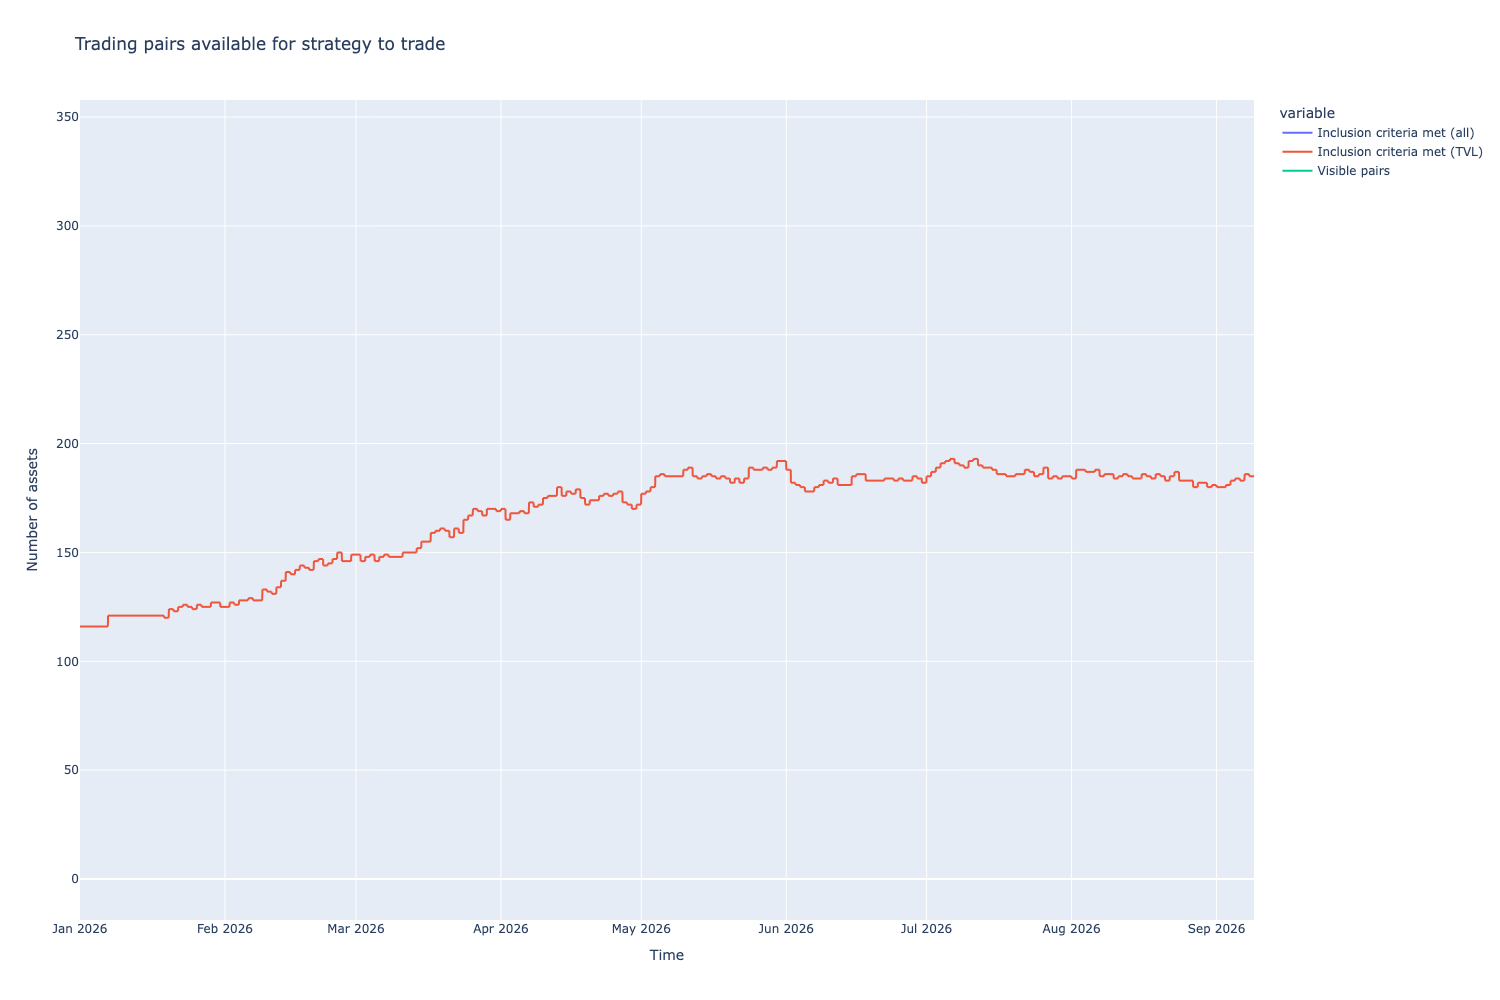

Head (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Visible pairs
2021-05-06,0.0,NaN,NaN
2021-05-07,0.0,NaN,NaN
2021-05-08,0.0,NaN,NaN
2021-05-09,0.0,NaN,NaN
2021-05-10,0.0,NaN,NaN


Tail (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Visible pairs
2026-09-08 20:00:00,NaN,185.0,NaN
2026-09-08 21:00:00,NaN,185.0,NaN
2026-09-08 22:00:00,NaN,185.0,NaN
2026-09-08 23:00:00,NaN,185.0,NaN
2026-09-09 00:00:00,182.0,185.0,339.0


In [7]:
fig, df = indicator_chart_renderer.render(available_trading_pairs, with_dataframe=True)
fig.show()
display_head_and_tail(df, head_rows=5, tail_rows=5)


## Included vault details

- Table of when each vault first entered the final investable set, with chain and TVL context.
- This is a detail table for the combined chart above, not a separate inclusion-criteria chart.

In [8]:
df = indicator_chart_renderer.render(inclusion_criteria_check_with_chain)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Head (5 rows)

,Included at,Ticker,Chain,Venue,TVL at inclusion,TVL at end
275397120,2023-04-26,Liquidator,hypercore,hyperliquid,63709.992506,1.556613e+04
269349635,2023-05-10,Hyperliquidity Provider (HLP),hypercore,hyperliquid,82331.181599,1.880126e+08
271831735,2023-12-06,CryptoZer0_,hypercore,hyperliquid,10343.017719,5.792265e+02
285065575,2024-03-06,Citadel,hypercore,hyperliquid,12252.277649,7.952879e+05
278006815,2024-03-20,Mahamor,hypercore,hyperliquid,8059.422905,1.335844e+04


Tail (5 rows)


,Included at,Ticker,Chain,Venue,TVL at inclusion,TVL at end
271231020,2026-08-28,gogogo,hypercore,hyperliquid,47227.268796,48763.448008
278179917,2026-09-03,Fadorador,hypercore,hyperliquid,7622.131269,7950.798822
273647210,2026-09-05,[ 3ee ] Systematic Alpha Mandate,hypercore,hyperliquid,11538.584876,1545.876808
280655394,2026-09-06,Helix,hypercore,hyperliquid,8816.789043,8206.823050
269499942,2026-09-08,Portola Strategies,hypercore,hyperliquid,86554.011010,86554.011010


# Time range for backtest

- Show how many vaults meet the TVL inclusion criteria across the research window.


Time range is 2026-01-01 00:00:00 - 2026-09-09 00:00:00


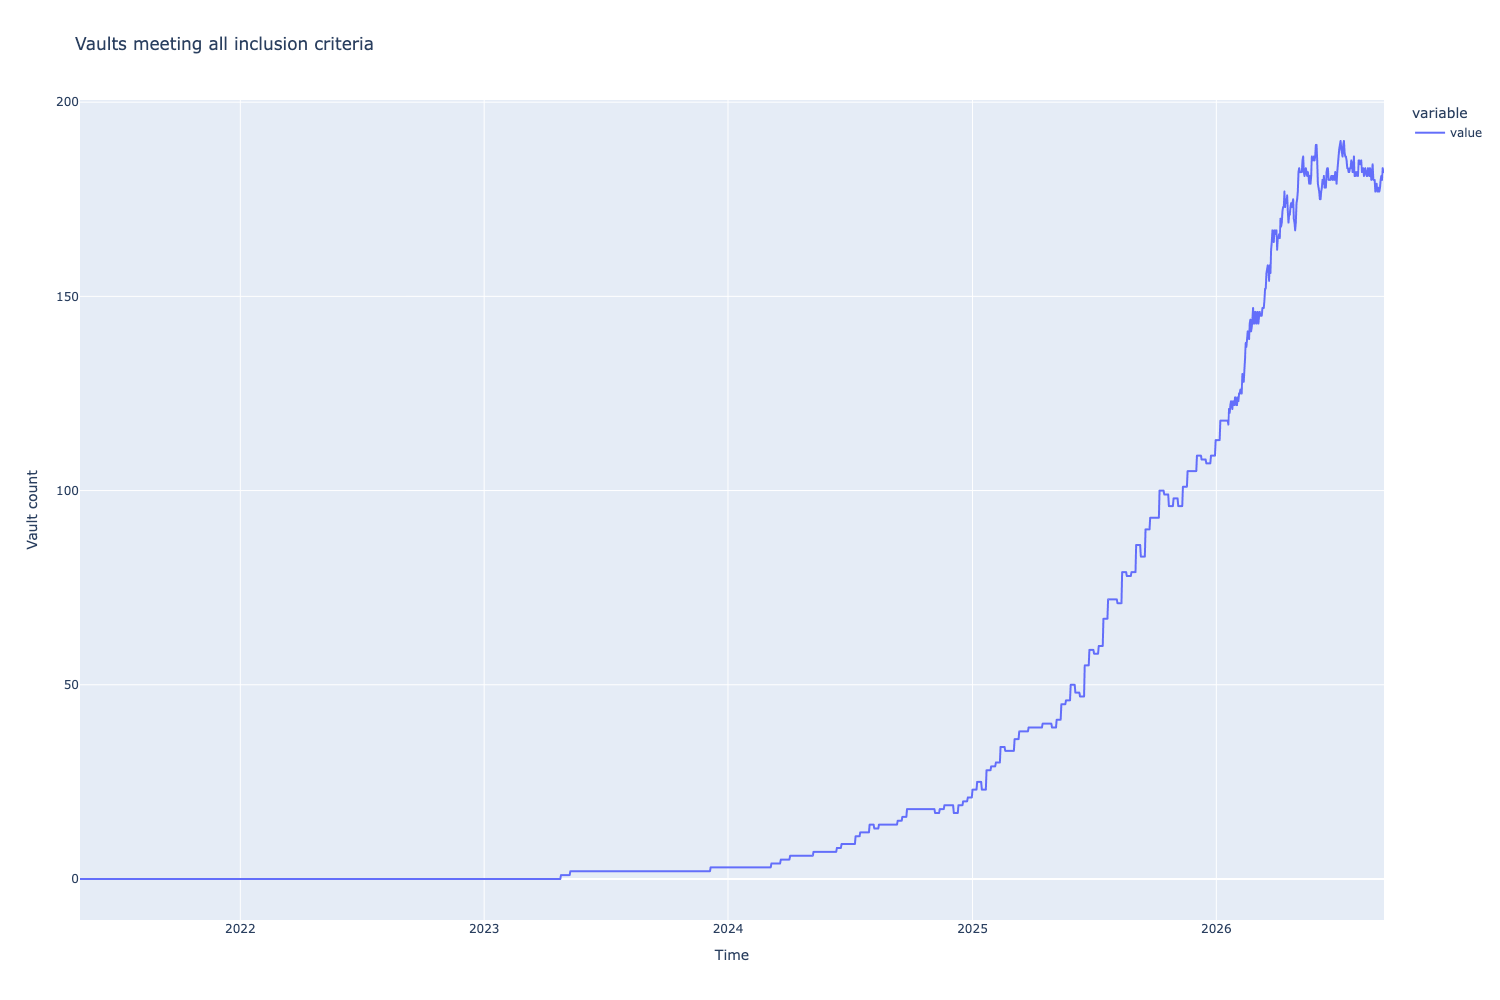

In [9]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

series = indicator_data.get_indicator_series(
    "all_criteria_included_pair_count",
)
fig = px.line(
    series,
    title="Vaults meeting all inclusion criteria",
)
fig.update_yaxes(title="Vault count")
fig.update_xaxes(title="Time")
fig.show()


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [10]:
import math
from dataclasses import replace
from types import MethodType


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def install_vault_redemption_pricing(pricing_model, capital_fee_rate: float) -> None:
    """Make backtest vault settlements retain their fee set at redemption request time.

    Async vault redemptions are priced when they settle, not when the request is
    made. Keep the per-pair fee on the pricing model so the later settlement
    cannot lose the performance fee to a fresh pair object.
    """
    if hasattr(pricing_model, "_vault_redemption_fee_by_pair_id"):
        return
    original_get_sell_price = pricing_model.get_sell_price

    def get_sell_price_with_redemption_fee(self, ts, pair, quantity):
        pricing = original_get_sell_price(ts, pair, quantity)
        if not pair.is_vault():
            return pricing
        fee = self._vault_redemption_fee_by_pair_id.get(pair.internal_id, capital_fee_rate)
        reserve = float(quantity) * pricing.mid_price
        return replace(
            pricing,
            price=float(pricing.mid_price * (1.0 - fee)),
            lp_fee=[reserve * fee],
            pair_fee=[fee],
            token_tax=reserve * fee,
            token_tax_percent=fee,
        )

    pricing_model._vault_redemption_fee_by_pair_id = {}
    pricing_model.get_sell_price = MethodType(get_sell_price_with_redemption_fee, pricing_model)


def get_remaining_cost_basis(position) -> float:
    """Calculate the weighted-average cost basis of the shares still held.

    Successful sells reduce the historical cost basis pro rata, while later
    deposits add their actual execution cost. This is the cost base against
    which HyperCore's redemption-time performance fee is charged.
    """
    quantity = 0.0
    cost_basis = 0.0
    for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
        trade_quantity = abs(float(trade.get_position_quantity()))
        if trade.is_buy():
            quantity += trade_quantity
            cost_basis += trade_quantity * float(trade.executed_price)
        elif trade.is_sell():
            assert quantity > 0, f"Cannot sell without a cost basis: {trade}"
            sold_quantity = min(trade_quantity, quantity)
            cost_basis *= (quantity - sold_quantity) / quantity
            quantity -= sold_quantity
    assert abs(quantity - float(position.get_quantity())) < 1e-8, (
        f"Cost-basis quantity mismatch for {position}: {quantity} vs {position.get_quantity()}"
    )
    return cost_basis


def refresh_vault_redemption_accounting(input: StrategyInput) -> pd.DataFrame:
    """Apply redemption performance fees and revalue every open vault position.

    HyperCore takes the performance fee only from positive redeemed profit.
    The pricing model accepts a sell-side tax, so convert the dollar fee to a
    per-share rate at the decision timestamp. Revaluing the position at that
    net price makes allocation use redeemable, rather than gross, equity.
    """
    parameters = input.parameters
    timestamp = input.timestamp
    revaluation_timestamp = timestamp.to_pydatetime() if hasattr(timestamp, "to_pydatetime") else timestamp
    pricing_model = input.pricing_model
    capital_fee_rate = float(parameters.vault_redemption_capital_fee)
    performance_fee_rate = float(parameters.vault_performance_fee)
    install_vault_redemption_pricing(pricing_model, capital_fee_rate)
    rows = []

    for position in input.state.portfolio.get_open_positions():
        if not position.pair.is_vault():
            continue
        quantity = float(position.get_quantity())
        if quantity <= 0:
            continue
        gross_price = float(
            pricing_model.get_sell_price(timestamp, position.pair, position.get_quantity()).mid_price
        )
        gross_value = quantity * gross_price
        cost_basis = get_remaining_cost_basis(position)
        performance_fee_usd = max(gross_value - cost_basis, 0.0) * performance_fee_rate
        performance_fee_rate_of_value = performance_fee_usd / gross_value if gross_value else 0.0
        effective_sell_tax = capital_fee_rate + performance_fee_rate_of_value
        assert 0 <= effective_sell_tax < 1, (
            f"Invalid effective redemption fee {effective_sell_tax:.2%} for {position}"
        )
        position.pair.base.other_data["sell_tax"] = effective_sell_tax
        input.strategy_universe.get_pair_by_id(position.pair.internal_id).base.other_data["sell_tax"] = effective_sell_tax
        pricing_model._vault_redemption_fee_by_pair_id[position.pair.internal_id] = effective_sell_tax
        net_price = gross_price * (1.0 - effective_sell_tax)
        position.revalue_base_asset(revaluation_timestamp, net_price)
        rows.append({
            "Position id": position.position_id,
            "Vault": position.pair.base.token_symbol,
            "Gross redeemable value": gross_value,
            "Remaining cost basis": cost_basis,
            "Performance fee accrued": performance_fee_usd,
            "Capital fee accrued": gross_value * capital_fee_rate,
            "Net redeemable value": gross_value - performance_fee_usd - gross_value * capital_fee_rate,
        })

    return pd.DataFrame(rows)


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


#: Vaults masked for this experiment only. **Not a blacklist.**
#:
#: **Empty in this notebook.** Realist Capital was masked through NB88 to NB92 to measure how much
#: of this chain's results depended on it; that question is answered and the mask is lifted here.
#: Its price data was never in doubt - a dense daily series, share price 2.11 to 9.26 across 2026,
#: corroborated by TVL growing $109k to $484k as outside money chased the same run.
#:
#: The machinery is kept rather than deleted so the filter below stays identical between this
#: notebook and NB88-NB92, and so re-masking is a one-line change rather than a re-edit of
#: `decide_trades`. An empty set means every vault that passes the blacklist is tradable.
#:
#: The distinction from `MANUAL_BLACKLIST` is deliberate and still holds: a blacklist entry says a
#: vault can never be traded, a mask says "run the counterfactual without it and see what changes".
MASKED_VAULTS: set[str] = set()

#: Vaults excluded by hand because their price series cannot support a position.
#:
#: This is a data-quality exclusion, not a performance judgement. A vault belongs here when its
#: share price is small enough that the feed's precision, rather than the vault's trading, drives
#: the returns the strategy sees.
#:
#: Keyed on pool address rather than name: token symbols are truncated to ten characters in this
#: universe, so names are not unique and not stable.
MANUAL_BLACKLIST = {
    # Scared Money - share price 0.00000800 to 0.00005568 across 2026, one significant figure of
    # precision, moving +-20% a day on rounding rather than performance. NB84 traced ~6 pp of
    # NB80's headline CAGR to a $10,781 position taken against $28,654 of vault TVL (38% of the
    # vault) and exited at +89%, which the fill-at-NAV assumption makes free.
    "0x5290ab34acb59cfe1371baa5782eba14433d308f",
}

def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    redemption_accounting = refresh_vault_redemption_accounting(input)
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Manually blacklisted: the price data is too broken to trade at the moment.
        if str(pair.pool_address).lower() in MANUAL_BLACKLIST:
            continue
        # Masked for this experiment only - see MASKED_VAULTS. Not a permanent exclusion.
        if str(pair.pool_address).lower() in MASKED_VAULTS:
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        # Restrict buys to available cash plus sells that will execute this
        # cycle. Suppressed sub-threshold sells cannot fund a new deposit.
        cap_buys_to_sync_cash=True,
        sync_cash_headroom_usd=parameters.sync_cash_headroom_usd,
    )
    for trade in trades:
        if trade.is_sell() and trade.pair.is_vault():
            trade.other_data["backtest_vault_redemption_fee"] = input.pricing_model._vault_redemption_fee_by_pair_id.get(
                trade.pair.internal_id,
                float(parameters.vault_redemption_capital_fee),
            )
            trade.planned_price = trade.planned_mid_price * (1.0 - trade.other_data["backtest_vault_redemption_fee"])
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades



# Backtest

- Run the `01-initial` configuration unchanged; only the reporting below differs.


In [11]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.statistics.key_metric import (
    calculate_cagr, calculate_max_drawdown, calculate_sharpe, calculate_sortino,
)

result = run_backtest_inline(
    name="NB02 lower-vol baseline, standard chart formatting",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")

#: Daily-basis returns, the convention used throughout this chain for headline metrics.
returns_daily = returns.resample('1D').sum(min_count=1).fillna(0.0).dropna()


#: Notebook-level summary table, rendered by the performance summary section below.
summary_df = pd.DataFrame(
    [
        ('Final equity USD', float(equity.iloc[-1])),
        ('Initial cash USD', float(Parameters.initial_cash)),
        ('Total return', float(equity.iloc[-1] / Parameters.initial_cash - 1)),
        ('CAGR', float(calculate_cagr(returns_daily))),
        ('Sharpe', float(calculate_sharpe(returns_daily, periods=365))),
        ('Sortino', float(calculate_sortino(returns_daily, periods=365))),
        ('Max drawdown', max_dd),
        ('Calmar', float(calculate_cagr(returns_daily)) / abs(max_dd) if max_dd else float('nan')),
        ('Positions', len(positions)),
        ('Trades', len(list(state.portfolio.get_all_trades()))),
        ('Decision cycles', len(cycle_stamps)),
    ],
    columns=['Metric', 'Value'],
)
display(summary_df)


2026-09-09 12:14:39,723 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-09 12:14:39,745 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


2026-09-09 12:14:39,767 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #95
  Estimated reserve 3208.655658787644126687291442, executed reserve 3153.462418772855133186414461
  Estimated quantity -1807.358340230454587072017602622509002685546875, executed quantity -1807.358340230454587072017602622509002685546875
  Reserve drift 1.720136 %, quantity drift 0.000000 %


2026-09-09 12:14:39,803 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #111
  Estimated reserve 3076.485336785541091209970801, executed reserve 3042.197876312657511193722692
  Estimated quantity -1779.199370326362213745596818625926971435546875, executed quantity -1779.199370326362213745596818625926971435546875
  Reserve drift 1.114501 %, quantity drift 0.000000 %


2026-09-09 12:14:39,854 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Gucky_1coi #131
  Estimated reserve 8455.107787702435563641300266, executed reserve 8369.178273907683374933232359
  Estimated quantity -3091.65139782867436224478296935558319091796875, executed quantity -3091.65139782867436224478296935558319091796875
  Reserve drift 1.016303 %, quantity drift 0.000000 %


...

2026-09-09 12:14:41,292 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #555
  Estimated reserve 1238.894759877592146903769366, executed reserve 1220.689544039575339218116414
  Estimated quantity -761.1061116230193874798715114593505859375, executed quantity -761.1061116230193874798715114593505859375
  Reserve drift 1.469472 %, quantity drift 0.000000 %


2026-09-09 12:14:41,307 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #561
  Estimated reserve 1154.370664345397112216617755, executed reserve 1136.553670836110247401225706
  Estimated quantity -269.07465954394916707315132953226566314697265625, executed quantity -269.07465954394916707315132953226566314697265625
  Reserve drift 1.543438 %, quantity drift 0.000000 %


2026-09-09 12:14:41,307 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #560
  Estimated reserve 873.0506477953530463910390874, executed reserve 860.2585955545784210326229847
  Estimated quantity -536.5939052253135059800115413963794708251953125, executed quantity -536.5939052253135059800115413963794708251953125
  Reserve drift 1.465213 %, quantity drift 0.000000 %


Final equity: $186,746  (start $150,000)
Max drawdown: -4.5%   distinct positions: 96   trades: 578
Decision cycles: 126 from 2026-01-01 00:00:00 to 2026-09-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $750.00


,Metric,Value
0,Final equity USD,186745.914252
1,Initial cash USD,150000.000000
2,Total return,0.244973
3,CAGR,0.378971
4,Sharpe,2.146010
5,Sortino,4.438910
6,Max drawdown,-0.044504
7,Calmar,8.515394
8,Positions,96.000000
9,Trades,578.000000


## Integrity: destroyed and stranded capital

NB80's accounting identity - `equity == initial cash + realised + unrealised` - cannot fail after
trade-executor [#1623](https://github.com/tradingstrategy-ai/trade-executor/pull/1623), because
realised + unrealised now *is* cash-flow profit, which reduces to cash + holdings. It is replaced
here by the check that caught the genuine
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) dust defect.

Equity reconciling against cash plus holdings is still worth asserting - it is cheap and it is the
one identity that was ever load-bearing - but it is reported as a reconciliation, not as a pass mark.


In [12]:
import pandas as pd

def audit_portfolio(portfolio) -> dict:
    """Screen one run for capital that entered a position and did not come back.

    Two failure modes, neither visible to the accounting identity, because the engine values a
    vanished position at zero and equity therefore still reconciles:

    - **destroyed**: funded with real cash, closed returning nothing
    - **stranded**: closed while still holding quantity
    """
    destroyed, stranded, stranded_usd = 0, 0, 0.0
    for position in portfolio.get_all_positions():
        if position.is_open() or position.is_credit_supply():
            continue
        funded = sum(abs(float(t.executed_reserve or 0))
                     for t in position.trades.values() if t.is_buy() and t.is_success())
        returned = sum(abs(float(t.executed_reserve or 0))
                       for t in position.trades.values() if t.is_sell() and t.is_success())
        # $100 funded against $1 returned keeps ordinary engine dust out of the count.
        if funded > 100 and returned < 1.0:
            destroyed += 1
        quantity = float(position.get_quantity() or 0)
        if abs(quantity) > 1e-9:
            stranded += 1
            stranded_usd += quantity * float(position.last_token_price or 0)

    cash = float(portfolio.get_cash())
    holdings = sum(float(p.get_value() or 0) for p in portfolio.open_positions.values())
    equity = float(portfolio.get_total_equity())
    return {
        "destroyed": destroyed,
        "stranded": stranded,
        "stranded USD": stranded_usd,
        "cash + holdings - equity": cash + holdings - equity,
    }


audit = audit_portfolio(state.portfolio)
display(pd.DataFrame([audit]).style.format({
    "stranded USD": "${:,.2f}", "cash + holdings - equity": "${:,.2f}",
}).hide(axis="index").set_caption("Integrity screen"))

if audit["destroyed"] or audit["stranded"]:
    print(f"FAILED: {audit['destroyed']} destroyed, {audit['stranded']} stranded position(s)")
else:
    print("Passed: no destroyed or stranded positions")


destroyed,stranded,stranded USD,cash + holdings - equity
0,0,$0.00,$0.00


Passed: no destroyed or stranded positions


## Redemption-fee audit

Verify every executed vault redemption charged exactly the 10% fee on positive profit plus 10 bps of gross redeemed capital.


In [13]:
def redemption_fee_audit(state_) -> pd.DataFrame:
    """Reconcile executed redemption prices against the configured fee treatment."""
    rows = []
    for position in state_.portfolio.get_all_positions():
        if not position.pair.is_vault():
            continue
        quantity = 0.0
        cost_basis = 0.0
        for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
            trade_quantity = abs(float(trade.get_position_quantity()))
            if trade.is_buy():
                quantity += trade_quantity
                cost_basis += trade_quantity * float(trade.executed_price)
                continue
            if not trade.is_sell():
                continue
            gross_price = float(trade.planned_mid_price)
            gross_proceeds = trade_quantity * gross_price
            released_cost_basis = cost_basis * trade_quantity / quantity
            configured_fee = float(trade.other_data["backtest_vault_redemption_fee"])
            capital_fee = gross_proceeds * Parameters.vault_redemption_capital_fee
            performance_fee = gross_proceeds * configured_fee - capital_fee
            actual_proceeds = trade_quantity * float(trade.executed_price)
            expected_proceeds = gross_proceeds * (1.0 - configured_fee)
            rows.append({
                "Vault": position.pair.base.token_symbol,
                "Redeemed at": trade.executed_at,
                "Gross proceeds": gross_proceeds,
                "Performance fee": performance_fee,
                "Capital fee": capital_fee,
                "Configured redemption fee": configured_fee,
                "Net proceeds": actual_proceeds,
                "Reconciliation error": actual_proceeds - expected_proceeds,
            })
            cost_basis -= released_cost_basis
            quantity -= trade_quantity
    return pd.DataFrame(rows)


redemption_fees = redemption_fee_audit(state)
assert len(redemption_fees), "Expected at least one vault redemption"
max_reconciliation_error = redemption_fees["Reconciliation error"].abs().max()
print(f"Maximum redemption-fee reconciliation error: ${max_reconciliation_error:,.8f}")
assert max_reconciliation_error < 1e-6, "Redemption fees did not reconcile"
display(
    redemption_fees.style.format({
        "Gross proceeds": "${:,.2f}",
        "Performance fee": "${:,.2f}",
        "Capital fee": "${:,.2f}",
        "Configured redemption fee": "{:.4%}",
        "Net proceeds": "${:,.2f}",
        "Reconciliation error": "${:,.8f}",
    }).set_caption("Every vault redemption reconciles to performance fee plus capital fee")
)


Maximum redemption-fee reconciliation error: $0.00000000


,Vault,Redeemed at,Gross proceeds,Performance fee,Capital fee,Configured redemption fee,Net proceeds,Reconciliation error
0,Citadel,2026-08-17 00:00:00,"$1,761.12",$4.93,$1.76,0.3800%,"$1,754.43",$0.00000000
1,Citadel,2026-08-19 00:00:00,"$1,374.58",$9.17,$1.37,0.7670%,"$1,364.04",$-0.00000000
2,Citadel,2026-08-31 00:00:00,$800.64,$5.49,$0.80,0.7863%,$794.35,$0.00000000
3,Citadel,2026-09-02 00:00:00,$900.79,$6.18,$0.90,0.7863%,$893.71,$0.00000000
4,Citadel,2026-09-06 00:00:00,$756.85,$5.13,$0.76,0.7779%,$750.96,$0.00000000
5,AceVault H,2026-08-21 00:00:00,"$4,827.89",$51.30,$4.83,1.1625%,"$4,771.76",$-0.00000000
6,AceVault H,2026-08-27 00:00:00,"$1,081.08",$13.54,$1.08,1.3524%,"$1,066.46",$0.00000000
7,AceVault H,2026-08-31 00:00:00,"$1,238.89",$16.97,$1.24,1.4695%,"$1,220.69",$0.00000000
8,AceVault H,2026-09-02 00:00:00,$873.05,$11.92,$0.87,1.4652%,$860.26,$0.00000000
9,Octavious,2026-09-02 00:00:00,"$1,154.37",$16.66,$1.15,1.5434%,"$1,136.55",$0.00000000


## Latest cycle cash and redemption snapshot

In [14]:
import re
import pandas as pd


def _extract_optional_usd(text: str, label: str) -> float:
    match = re.search(rf"{re.escape(label)}: ([0-9,]+(?:\.[0-9]+)?) USD", text)
    return float(match.group(1).replace(',', '')) if match else float('nan')


message_map = state.visualisation.get_messages_tail(2)
latest_cycle_label = list(message_map.keys())[0]
latest_message = list(message_map.values())[0]

if 'chart_renderer' not in globals():
    chart_renderer = ChartBacktestRenderingSetup(
        registry=charts,
        strategy_input_indicators=indicator_data,
        state=state,
        backtest_start_at=Parameters.backtest_start,
        backtest_end_at=Parameters.backtest_end,
    )

alpha_df = chart_renderer.render(alpha_model_diagnostics)
if isinstance(alpha_df.columns, pd.MultiIndex):
    alpha_df.columns = [c[0] for c in alpha_df.columns]

accepted_size_col = next(c for c in alpha_df.columns if 'Accepted size' in str(c))
flags_col = next(c for c in alpha_df.columns if 'Flags' in str(c))

accepted_sizes = pd.to_numeric(alpha_df[accepted_size_col], errors='coerce').fillna(0.0)
accepted_mask = accepted_sizes > 0
flags = alpha_df[flags_col].fillna('').astype(str)

total_equity = _extract_optional_usd(latest_message, 'Total equity')
cash = _extract_optional_usd(latest_message, 'Cash')
redeemable_capital = _extract_optional_usd(latest_message, 'Redeemable capital')
pending_redemptions = _extract_optional_usd(latest_message, 'Pending redemptions')
investable = _extract_optional_usd(latest_message, 'Investable equity')
accepted_investable = _extract_optional_usd(latest_message, 'Accepted investable equity')
allocated_to_signals = _extract_optional_usd(latest_message, 'Allocated to signals')
discarded_lit_liquidity = _extract_optional_usd(latest_message, 'Discarded allocation because of lack of lit liquidity')

benchmark_df = pd.DataFrame(
    [
        ('Final cycle', latest_cycle_label),
        ('Total equity USD', total_equity),
        ('Cash USD', cash),
        ('Cash % of equity', cash / total_equity if total_equity else float('nan')),
        ('Redeemable capital USD', redeemable_capital),
        ('Pending redemptions USD', pending_redemptions),
        ('Investable equity USD', investable),
        ('Accepted investable equity USD', accepted_investable),
        ('Accepted / investable %', accepted_investable / investable if investable else float('nan')),
        ('Allocated to signals USD', allocated_to_signals),
        ('Discarded because of lit liquidity USD', discarded_lit_liquidity),
        ('Unaccepted investable USD', investable - accepted_investable),
        ('Unaccepted / investable %', (investable - accepted_investable) / investable if investable else float('nan')),
        ('Accepted positions', int(accepted_mask.sum())),
        ('Mean accepted position USD', accepted_sizes[accepted_mask].mean()),
        ('Median accepted position USD', accepted_sizes[accepted_mask].median()),
        ('Flags: capped_by_pool_size', int(flags.str.contains('capped_by_pool_size').sum())),
        ('Flags: individual_trade_size_too_small', int(flags.str.contains('individual_trade_size_too_small').sum())),
    ],
    columns=['Metric', 'Value'],
)

display(benchmark_df)


,Metric,Value
0,Final cycle,2026-09-08 00:00:00
1,Total equity USD,186878.4
2,Cash USD,16929.32
3,Cash % of equity,0.09059
4,Redeemable capital USD,169949.08
5,Pending redemptions USD,0.0
6,Investable equity USD,183140.83
7,Accepted investable equity USD,163635.96
8,Accepted / investable %,0.893498
9,Allocated to signals USD,163635.96


## Capital utilisation through time

In [15]:
import datetime
import re
import pandas as pd


def _extract_optional_usd_series(text: str, label: str) -> float:
    match = re.search(rf"{re.escape(label)}: ([0-9,]+(?:\.[0-9]+)?) USD", text)
    return float(match.group(1).replace(',', '')) if match else float('nan')


def _extract_optional_int_series(text: str, label: str) -> int:
    match = re.search(rf"{re.escape(label)}: ([0-9]+)", text)
    return int(match.group(1)) if match else 0


rows = []
message_tuples = sorted(state.visualisation.messages.items(), key=lambda x: x[0])
for unix_ts, messages in message_tuples:
    if not messages:
        continue
    message = '\n'.join(messages)
    dt = datetime.datetime.utcfromtimestamp(unix_ts)
    total_equity = _extract_optional_usd_series(message, 'Total equity')
    cash = _extract_optional_usd_series(message, 'Cash')
    redeemable = _extract_optional_usd_series(message, 'Redeemable capital')
    pending = _extract_optional_usd_series(message, 'Pending redemptions')
    investable = _extract_optional_usd_series(message, 'Investable equity')
    accepted = _extract_optional_usd_series(message, 'Accepted investable equity')
    allocated = _extract_optional_usd_series(message, 'Allocated to signals')
    discarded = _extract_optional_usd_series(message, 'Discarded allocation because of lack of lit liquidity')
    rows.append({
        'timestamp': dt,
        'total_equity_usd': total_equity,
        'cash_usd': cash,
        'cash_pct_of_equity': cash / total_equity if total_equity else float('nan'),
        'redeemable_capital_usd': redeemable,
        'pending_redemptions_usd': pending,
        'investable_equity_usd': investable,
        'accepted_investable_equity_usd': accepted,
        'accepted_pct_of_investable': accepted / investable if investable else float('nan'),
        'unaccepted_pct_of_investable': (investable - accepted) / investable if investable else float('nan'),
        'allocated_to_signals_usd': allocated,
        'discarded_due_to_lit_liquidity_usd': discarded,
        'capped_by_pool_size_count': _extract_optional_int_series(message, 'Signals with flag capped_by_pool_size'),
        'individual_trade_size_too_small_count': _extract_optional_int_series(message, 'Signals with flag individual_trade_size_too_small'),
    })

utilisation_df = pd.DataFrame(rows).set_index('timestamp')
display(utilisation_df.tail(10))


/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_87986/1364199140.py:22: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.datetime.utcfromtimestamp(unix_ts)


,total_equity_usd,cash_usd,cash_pct_of_equity,redeemable_capital_usd,pending_redemptions_usd,investable_equity_usd,accepted_investable_equity_usd,accepted_pct_of_investable,unaccepted_pct_of_investable,allocated_to_signals_usd,discarded_due_to_lit_liquidity_usd,capped_by_pool_size_count,individual_trade_size_too_small_count
timestamp,,,,,,,,,,,,,
2026-08-21,186659.25,3241.16,0.017364,183418.09,0.0,182926.06,175154.70,0.957516,0.042484,175154.70,19753.73,3,0
2026-08-23,191151.76,11411.24,0.059697,179740.52,0.0,187328.72,187328.72,1.000000,0.000000,187328.72,37765.08,2,0
2026-08-25,190464.50,3771.31,0.019801,186693.20,0.0,186655.21,182350.53,0.976938,0.023062,182350.53,11308.58,3,1
2026-08-27,192326.84,7893.98,0.041045,184432.86,0.0,188480.30,184587.55,0.979347,0.020653,184587.55,9861.37,3,2
2026-08-29,191974.90,7319.51,0.038127,184655.39,0.0,188135.40,188060.75,0.999603,0.000397,188060.75,1851.78,3,2
2026-08-31,190873.42,3294.22,0.017259,187579.21,0.0,187055.96,185751.90,0.993029,0.006971,185751.90,4319.33,3,2
2026-09-02,188087.92,4958.55,0.026363,183129.37,0.0,184326.16,164917.12,0.894703,0.105297,164917.12,85343.46,4,2
2026-09-04,190144.11,22501.66,0.118340,167642.46,0.0,186341.23,155583.96,0.834941,0.165059,155583.96,96638.52,4,2
2026-09-06,187787.58,33684.07,0.179373,154103.51,0.0,184031.83,170716.94,0.927649,0.072351,170716.94,77571.42,4,1


## Capital utilisation summary

In [16]:
utilisation_summary = pd.DataFrame(
    [
        ('Mean accepted / investable %', utilisation_df['accepted_pct_of_investable'].mean()),
        ('Median accepted / investable %', utilisation_df['accepted_pct_of_investable'].median()),
        ('Min accepted / investable %', utilisation_df['accepted_pct_of_investable'].min()),
        ('Max accepted / investable %', utilisation_df['accepted_pct_of_investable'].max()),
        ('Mean cash % of equity', utilisation_df['cash_pct_of_equity'].mean()),
        ('Median cash % of equity', utilisation_df['cash_pct_of_equity'].median()),
        ('Max cash % of equity', utilisation_df['cash_pct_of_equity'].max()),
        ('Mean redeemable capital USD', utilisation_df['redeemable_capital_usd'].mean()),
        ('Mean pending redemptions USD', utilisation_df['pending_redemptions_usd'].mean()),
        ('Mean capped_by_pool_size count', utilisation_df['capped_by_pool_size_count'].mean()),
        ('Mean too-small count', utilisation_df['individual_trade_size_too_small_count'].mean()),
        ('Share of cycles above 50% deployment', (utilisation_df['accepted_pct_of_investable'] > 0.50).mean()),
        ('Share of cycles above 75% deployment', (utilisation_df['accepted_pct_of_investable'] > 0.75).mean()),
    ],
    columns=['Metric', 'Value'],
)
display(utilisation_summary)


,Metric,Value
0,Mean accepted / investable %,0.990826
1,Median accepted / investable %,1.000000
2,Min accepted / investable %,0.834941
3,Max accepted / investable %,1.000000
4,Mean cash % of equity,0.034927
5,Median cash % of equity,0.019211
6,Max cash % of equity,1.000000
7,Mean redeemable capital USD,161158.826587
8,Mean pending redemptions USD,0.000000
9,Mean capped_by_pool_size count,2.222222


## Capital utilisation charts

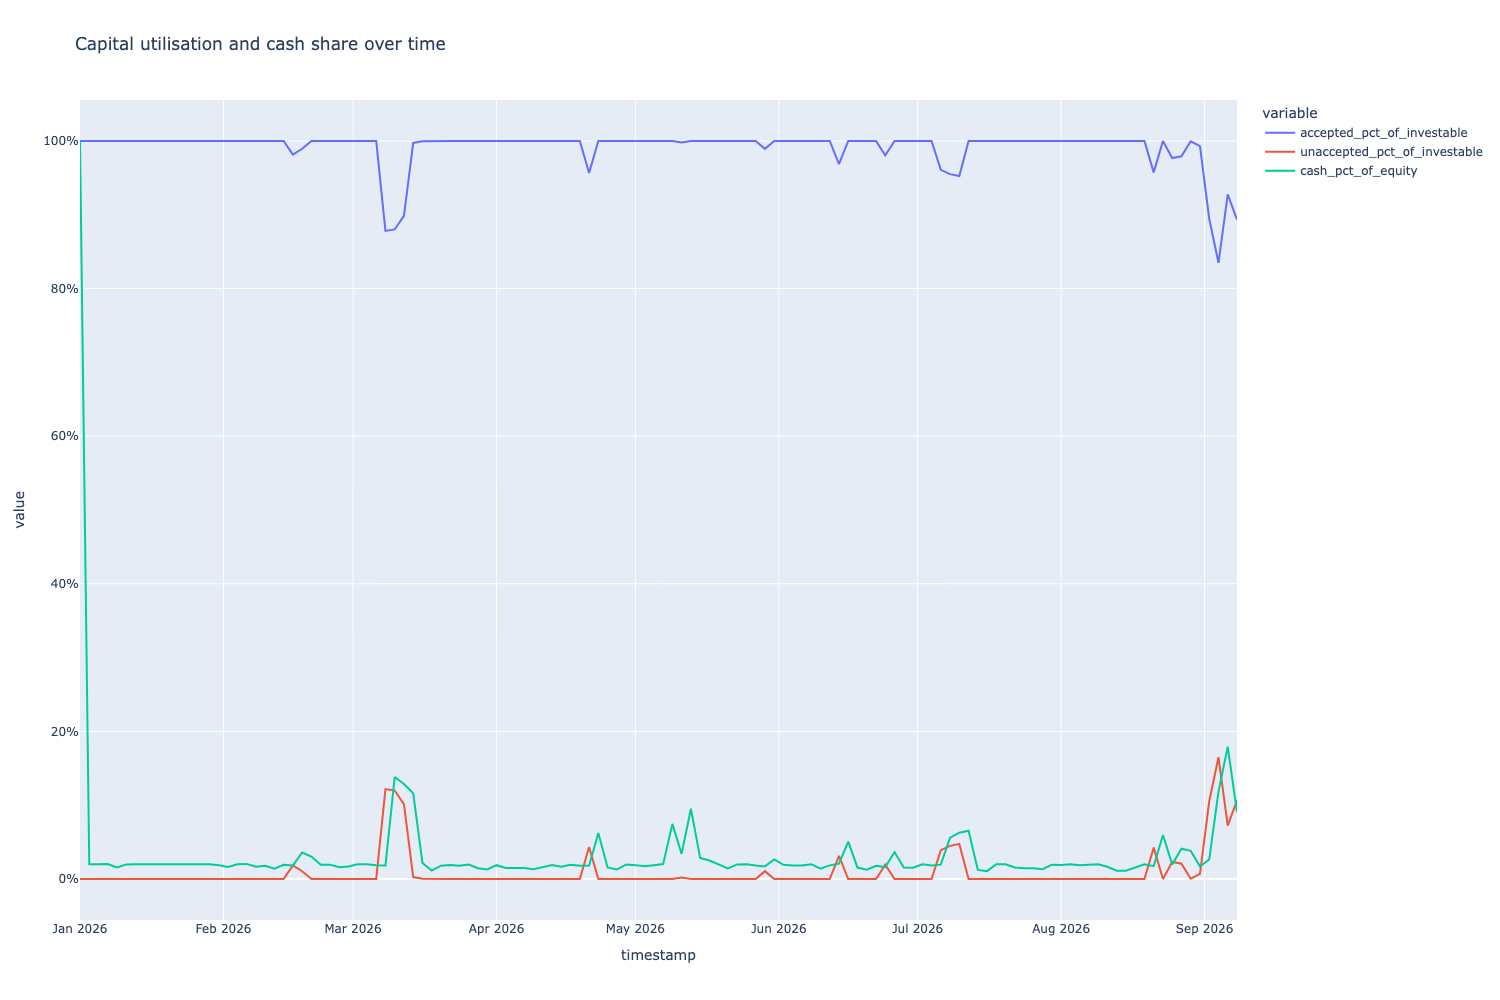

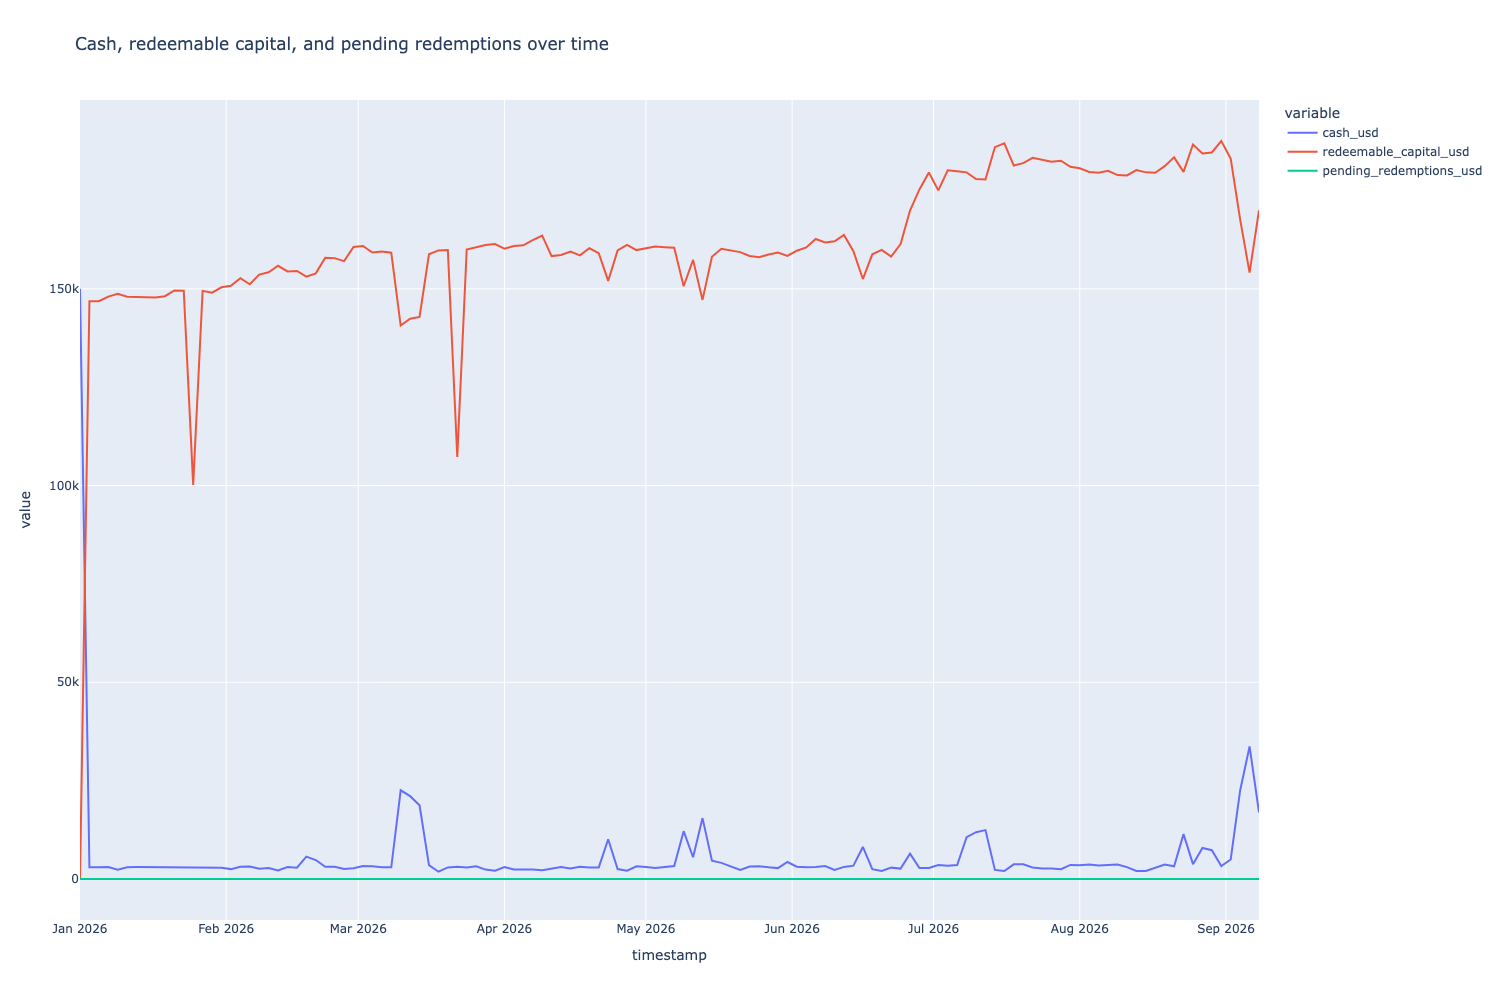

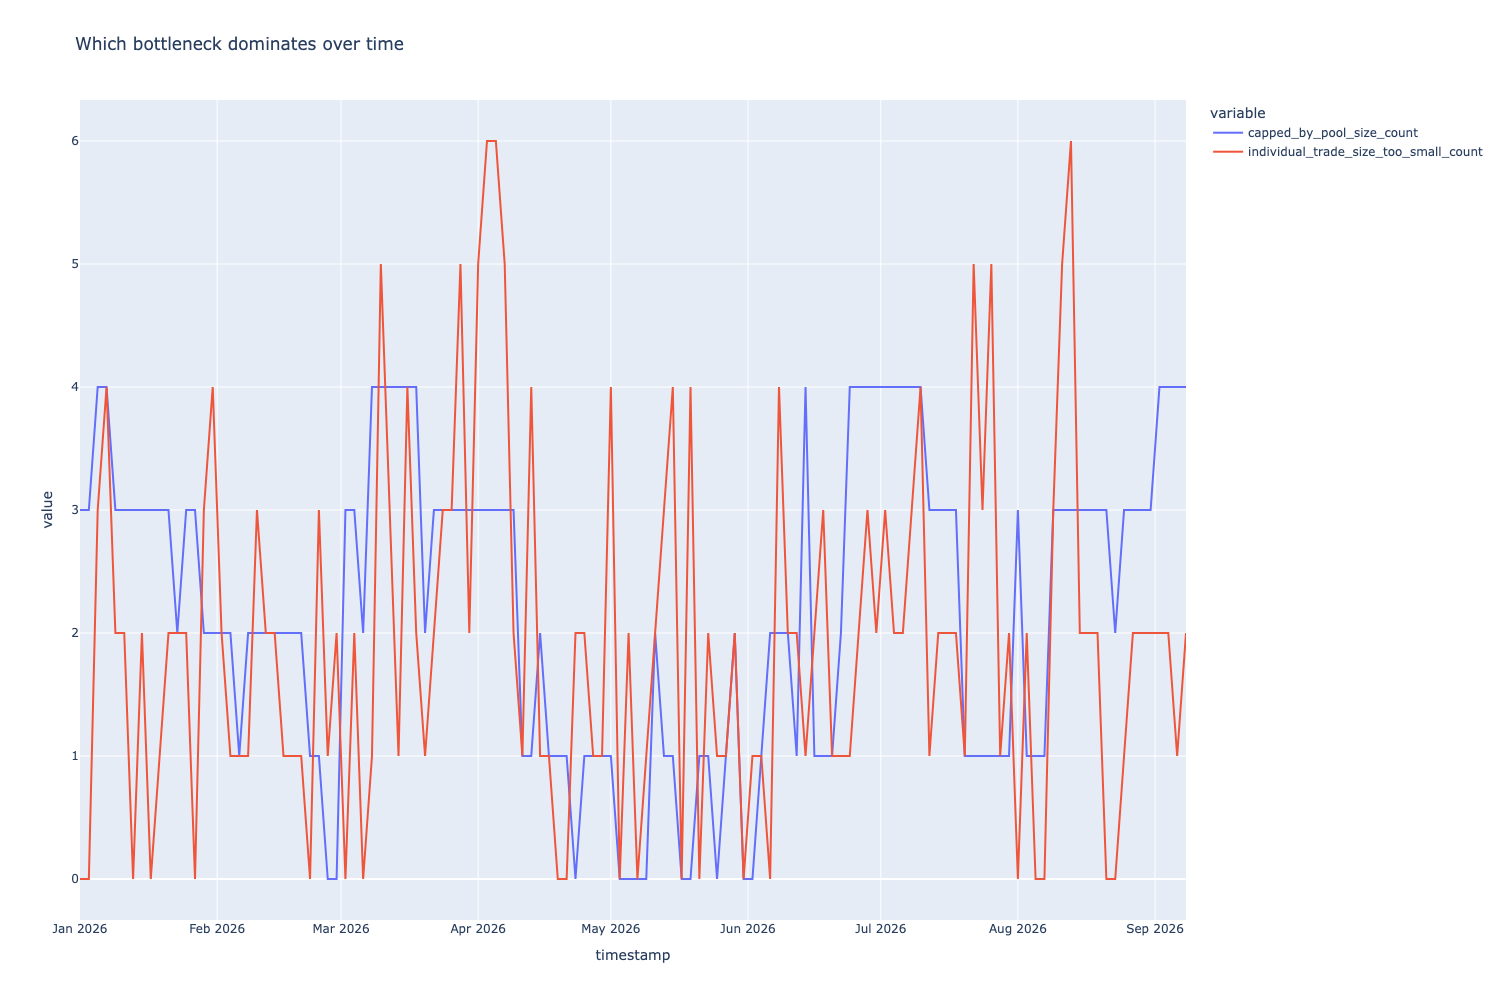

In [17]:
import plotly.express as px

plot_df = utilisation_df.reset_index()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['accepted_pct_of_investable', 'unaccepted_pct_of_investable', 'cash_pct_of_equity'],
    title='Capital utilisation and cash share over time',
)
fig.update_yaxes(tickformat='.0%')
fig.show()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['cash_usd', 'redeemable_capital_usd', 'pending_redemptions_usd'],
    title='Cash, redeemable capital, and pending redemptions over time',
)
fig.show()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['capped_by_pool_size_count', 'individual_trade_size_too_small_count'],
    title='Which bottleneck dominates over time',
)
fig.show()


## Survivor selection

Head (5 rows)


/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_87986/2566027933.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.datetime.utcfromtimestamp(unix_ts)


,candidate_signals_created,selected_survivor_signals,open_positions
timestamp,,,
2026-01-01,106,6,6
2026-01-03,106,6,6
2026-01-05,106,8,6
2026-01-07,106,6,6
2026-01-09,110,8,6


Tail (5 rows)


,candidate_signals_created,selected_survivor_signals,open_positions
timestamp,,,
2026-08-31,158,6,6
2026-09-02,161,7,6
2026-09-04,164,7,6
2026-09-06,169,7,6
2026-09-08,172,7,6


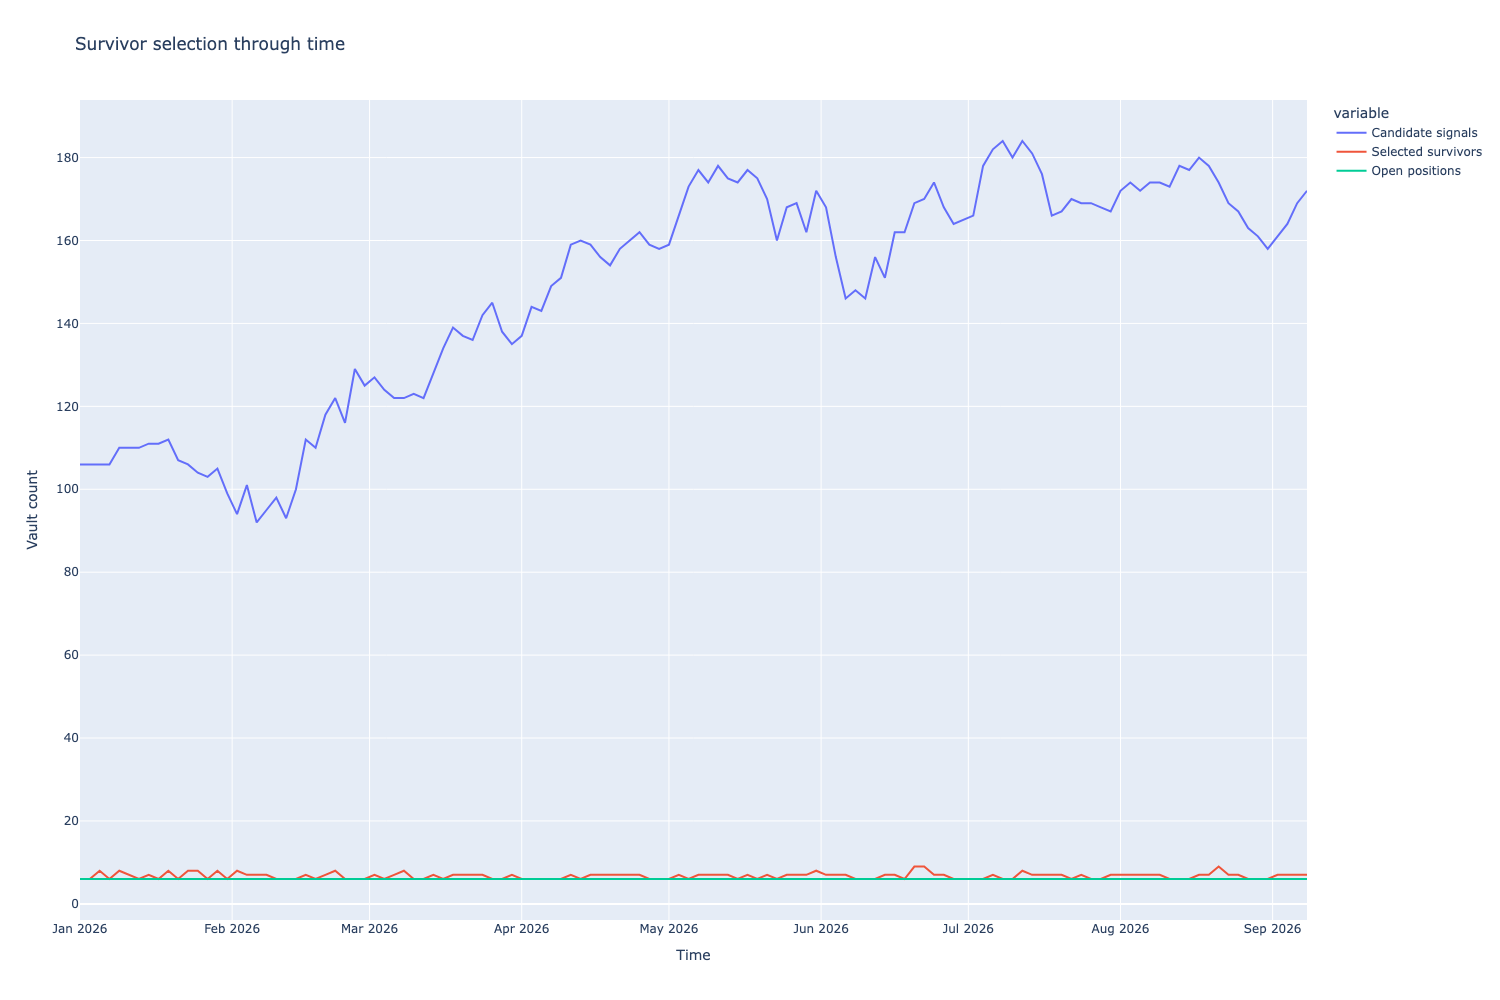

In [18]:
#: `01-initial`'s backtest cell does not build a selection diagnostics frame, so it is
#: reconstructed here from the per-cycle strategy messages, the same way the capital
#: utilisation frame above is built.
def _extract_int(text: str, label: str) -> int:
    match = re.search(rf"{re.escape(label)}: ([0-9]+)", text)
    return int(match.group(1)) if match else 0


_all_positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]


def _open_position_count(when: datetime.datetime) -> int:
    return sum(
        1
        for p in _all_positions
        if p.opened_at <= when and (p.closed_at is None or p.closed_at > when)
    )


rows = []
for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda x: x[0]):
    if not messages:
        continue
    message = '\n'.join(messages)
    dt = datetime.datetime.utcfromtimestamp(unix_ts)
    rows.append({
        'timestamp': dt,
        'candidate_signals_created': _extract_int(message, 'Candidate signals created'),
        'selected_survivor_signals': _extract_int(message, 'Selected survivor signals'),
        'open_positions': _open_position_count(dt),
    })

selection_diagnostics_df = pd.DataFrame(rows).set_index('timestamp')

display_head_and_tail(selection_diagnostics_df, head_rows=5, tail_rows=5)

plot_df = selection_diagnostics_df.reset_index().rename(
    columns={
        'candidate_signals_created': 'Candidate signals',
        'selected_survivor_signals': 'Selected survivors',
        'open_positions': 'Open positions',
    }
)
fig = px.line(
    plot_df,
    x='timestamp',
    y=['Candidate signals', 'Selected survivors', 'Open positions'],
    title='Survivor selection through time',
)
fig.update_yaxes(title='Vault count')
fig.update_xaxes(title='Time')
fig.show()


# Performance summary

- Start with the notebook-specific summary table, then inspect the standard strategy performance view.

In [19]:
chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)

display(summary_df)

df = chart_renderer.render(performance_metrics)
display(df)


,Metric,Value
0,Final equity USD,186745.914252
1,Initial cash USD,150000.000000
2,Total return,0.244973
3,CAGR,0.378971
4,Sharpe,2.146010
5,Sortino,4.438910
6,Max drawdown,-0.044504
7,Calmar,8.515394
8,Positions,96.000000
9,Trades,578.000000


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-09-08,2026-09-08,2026-09-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,50.0%,99.0%,99.0%
Cumulative Return,24.62%,-14.0%,-20.94%
CAGR﹪,37.9%,-19.76%,-29.04%
Sharpe,2.15,-0.24,-0.22
Prob. Sharpe Ratio,98.34%,42.22%,42.79%
Smart Sharpe,2.12,-0.23,-0.22
Sortino,4.44,-0.34,-0.33


# Equity curve

- Compare the strategy equity curve against the ETH benchmark.

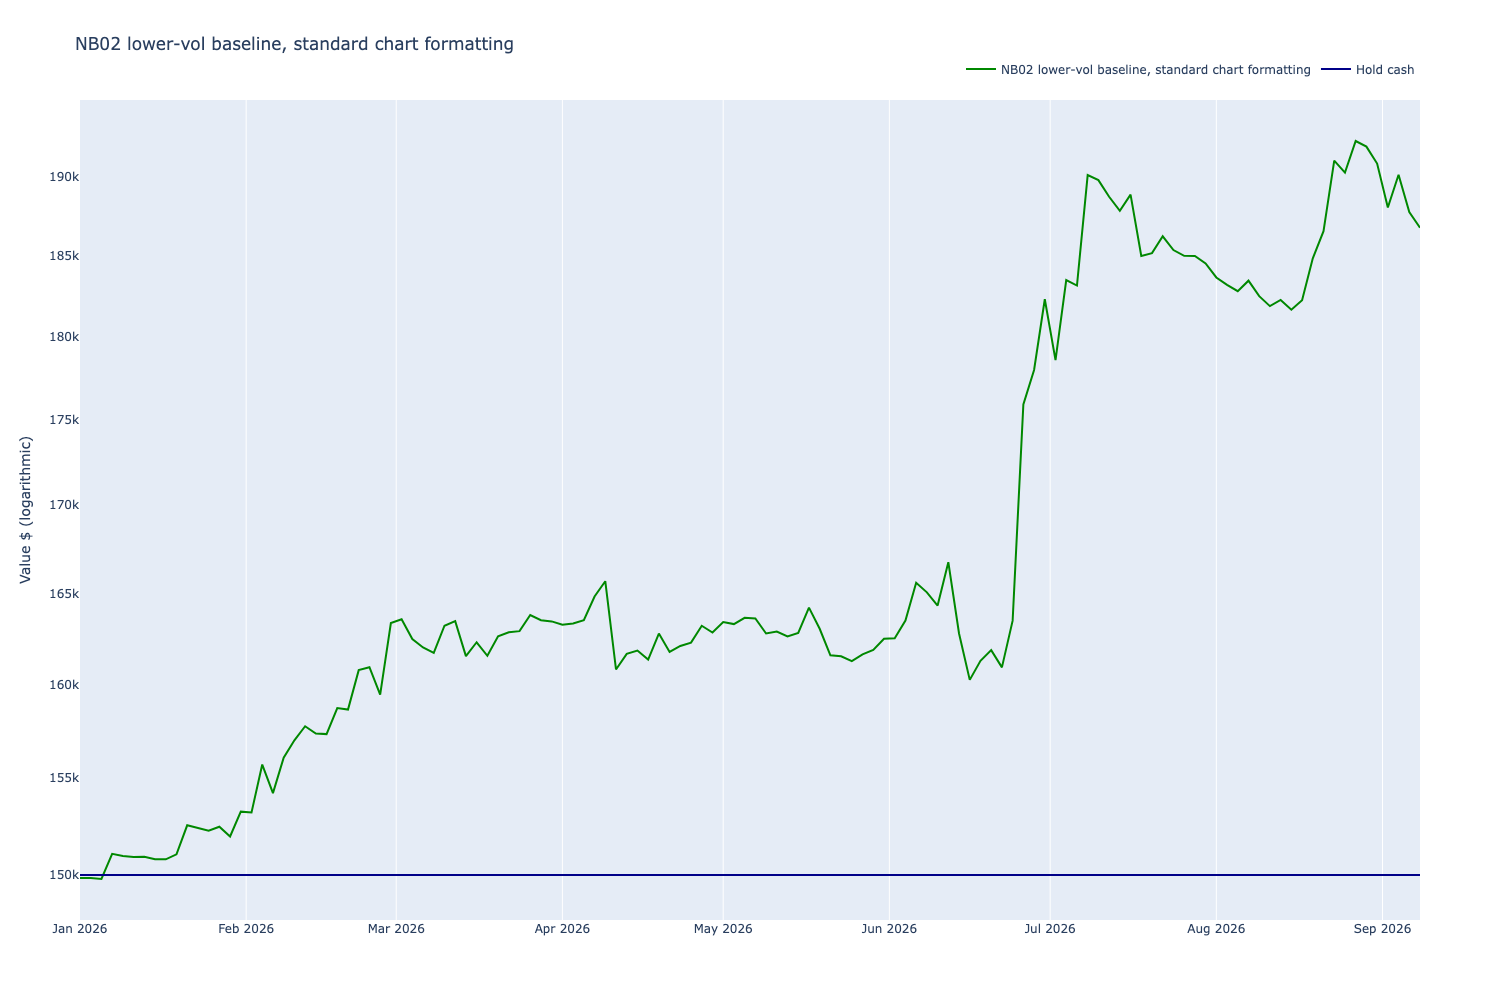

In [20]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

## Equity curve with drawdown

- View the same equity path with drawdown overlaid.

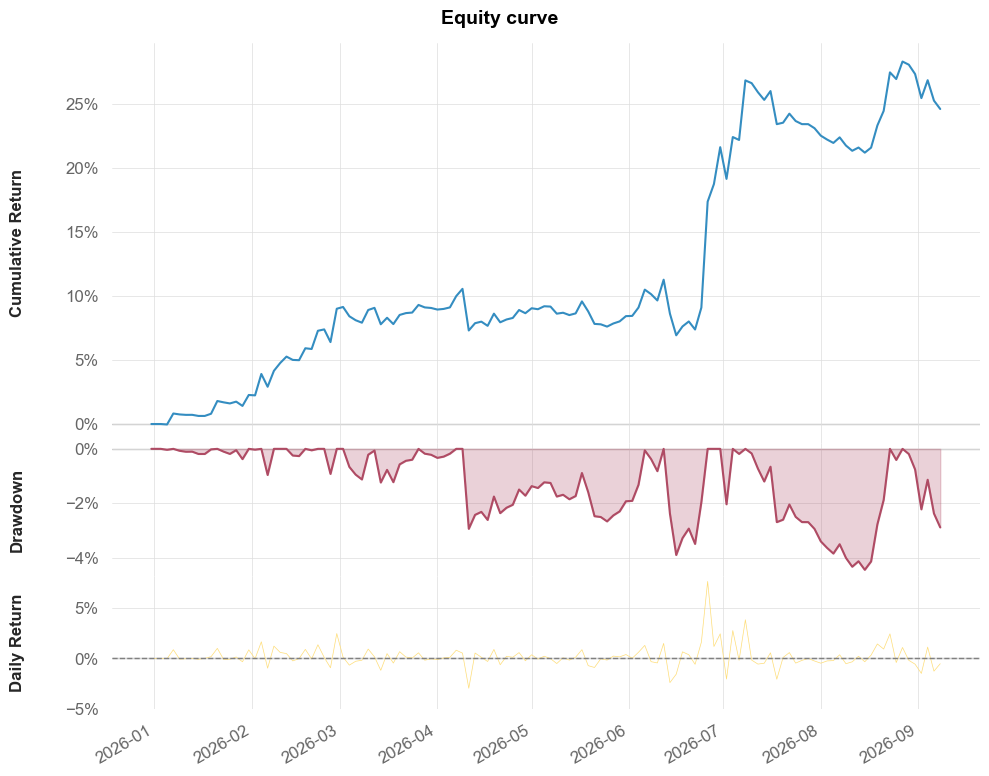

In [21]:
fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)

# Asset weights

- Review how the portfolio distributes risk across vaults and chains.

## Portfolio equity curve breakdown by asset

- Show how the main vault holdings contribute to the cumulative equity curve.

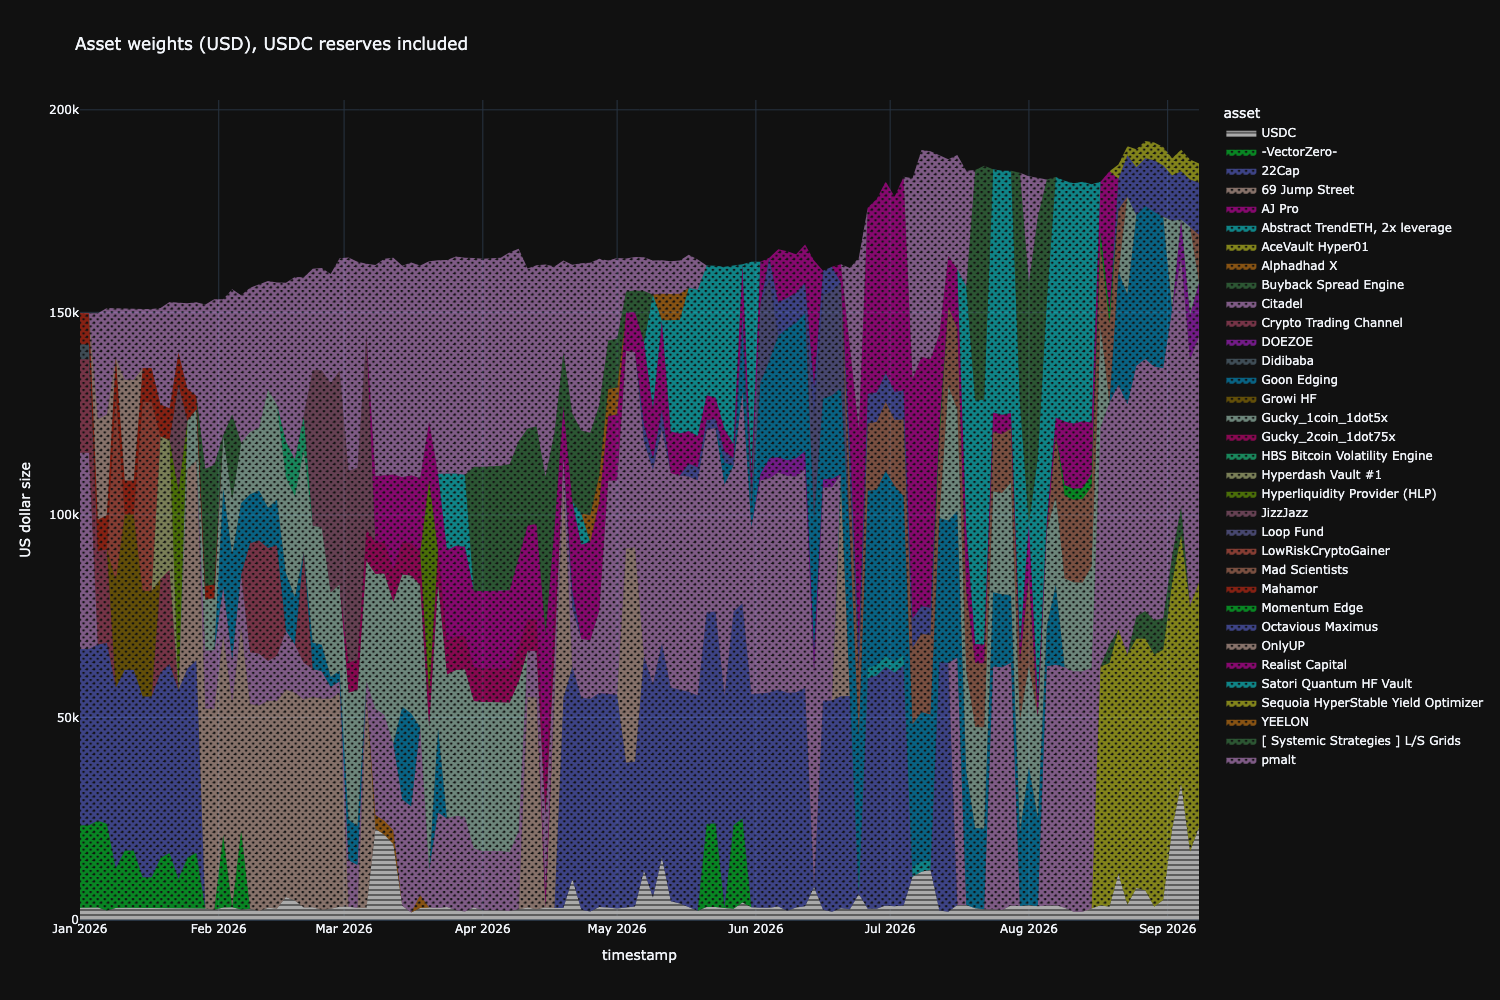

In [22]:
fig = chart_renderer.render(equity_curve_by_asset)
fig.show()

## Portfolio equity curve breakdown by chain

- Break the realised equity curve down by chain exposure.

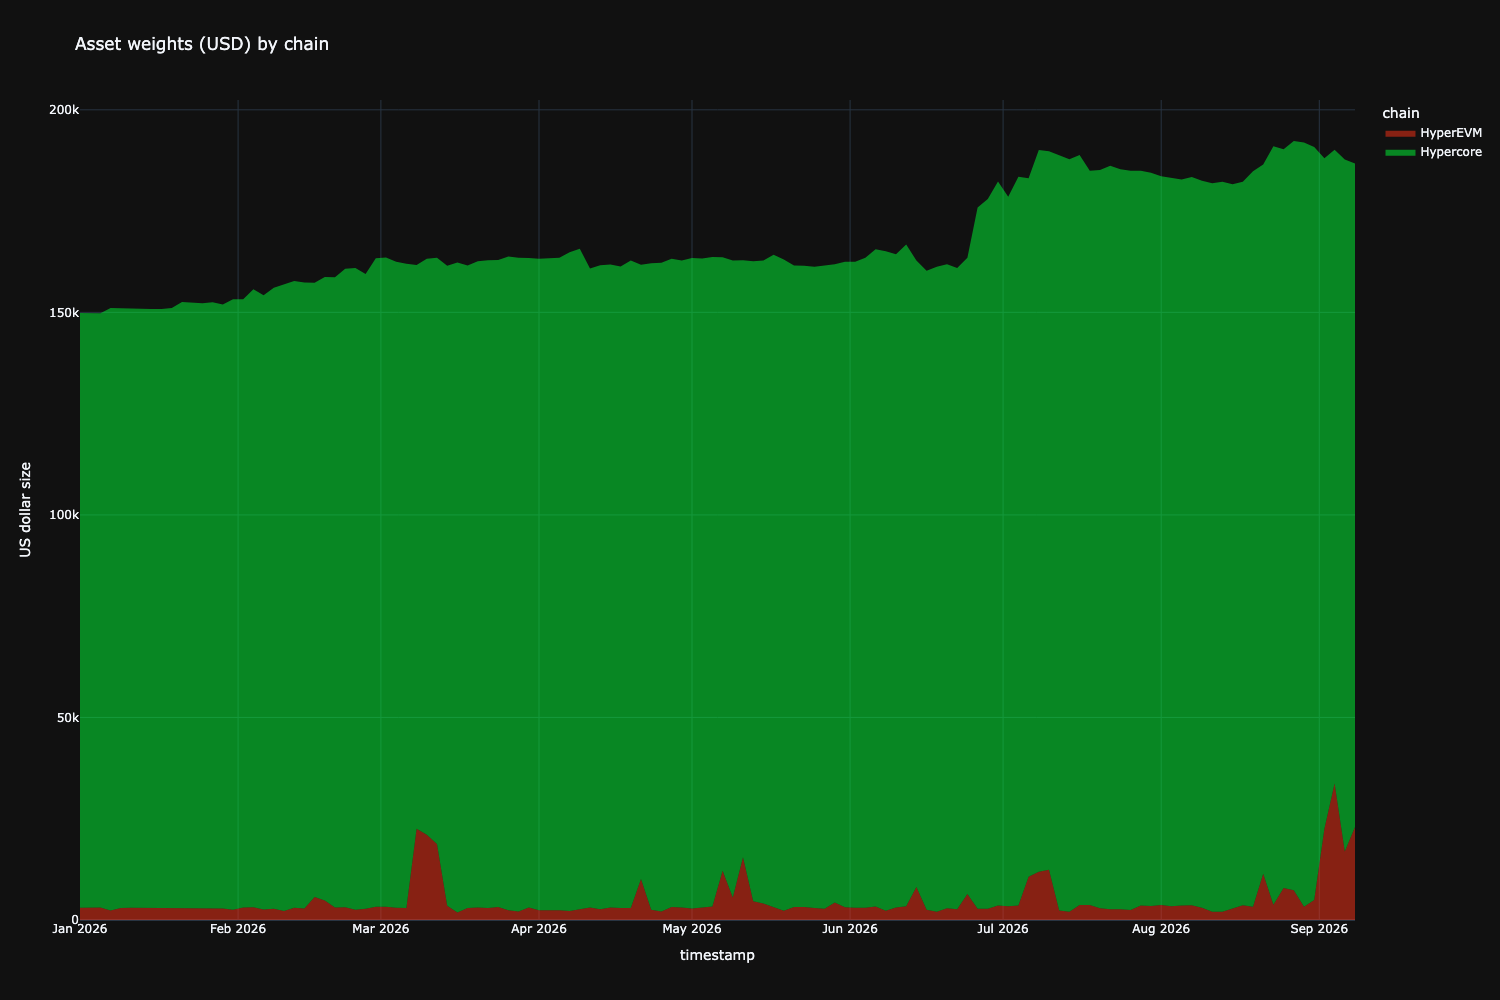

In [23]:
fig, chain_breakdown_df = chart_renderer.render(equity_curve_by_chain)
fig.show()



## Weight allocation statistics

- Keep the compact allocation statistics table as a quick summary.

In [24]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

stats = chart_renderer.render(weight_allocation_statistics)
display_dataframe_with_html(stats)

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-08-29,Citadel,"$62,529.20",
Min position (excluding USDC),2026-06-02,DOEZOE,"$1,474.34",
Mean position (excluding USDC),,,"$27,141.78",
Max position (excluding USDC),2026-09-04,Citadel,39.31%,
Min position (excluding USDC),2026-06-02,DOEZOE,0.92%,
Mean position (excluding USDC),,,16.67%,
Max position (including USDC),2026-06-16,Citadel,32.88%,
Min position (including USDC),2026-06-02,DOEZOE,0.91%,
Mean position (including USDC),,,14.29%,


# Rolling performance

- Track the medium-term return profile and risk-adjusted return profile through time using a fixed 3-month window.


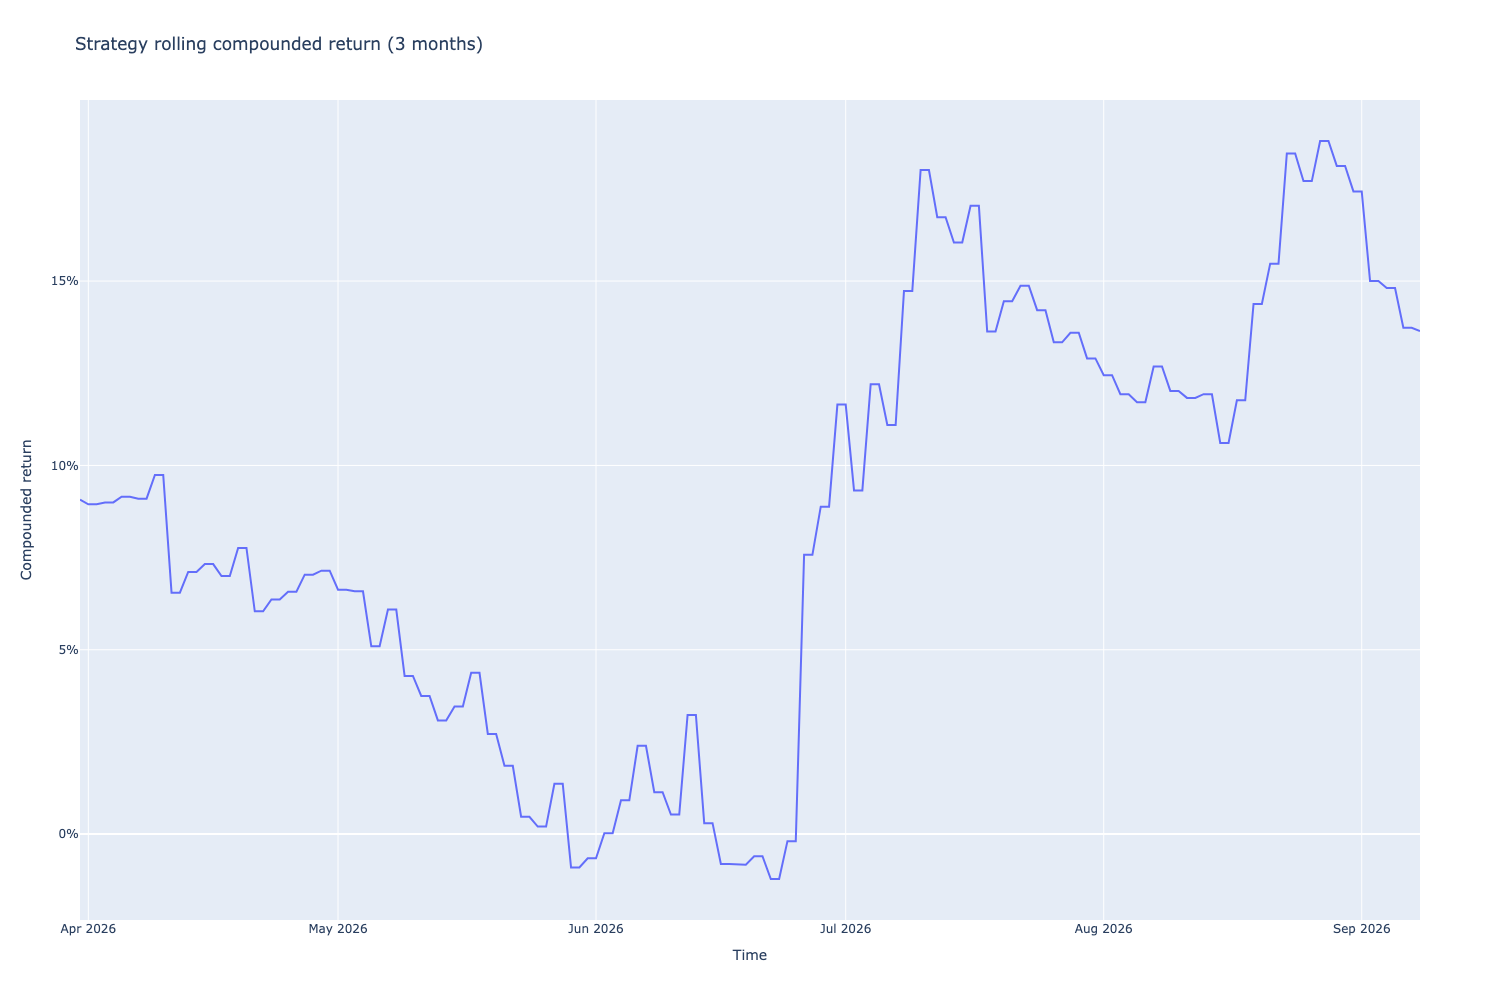

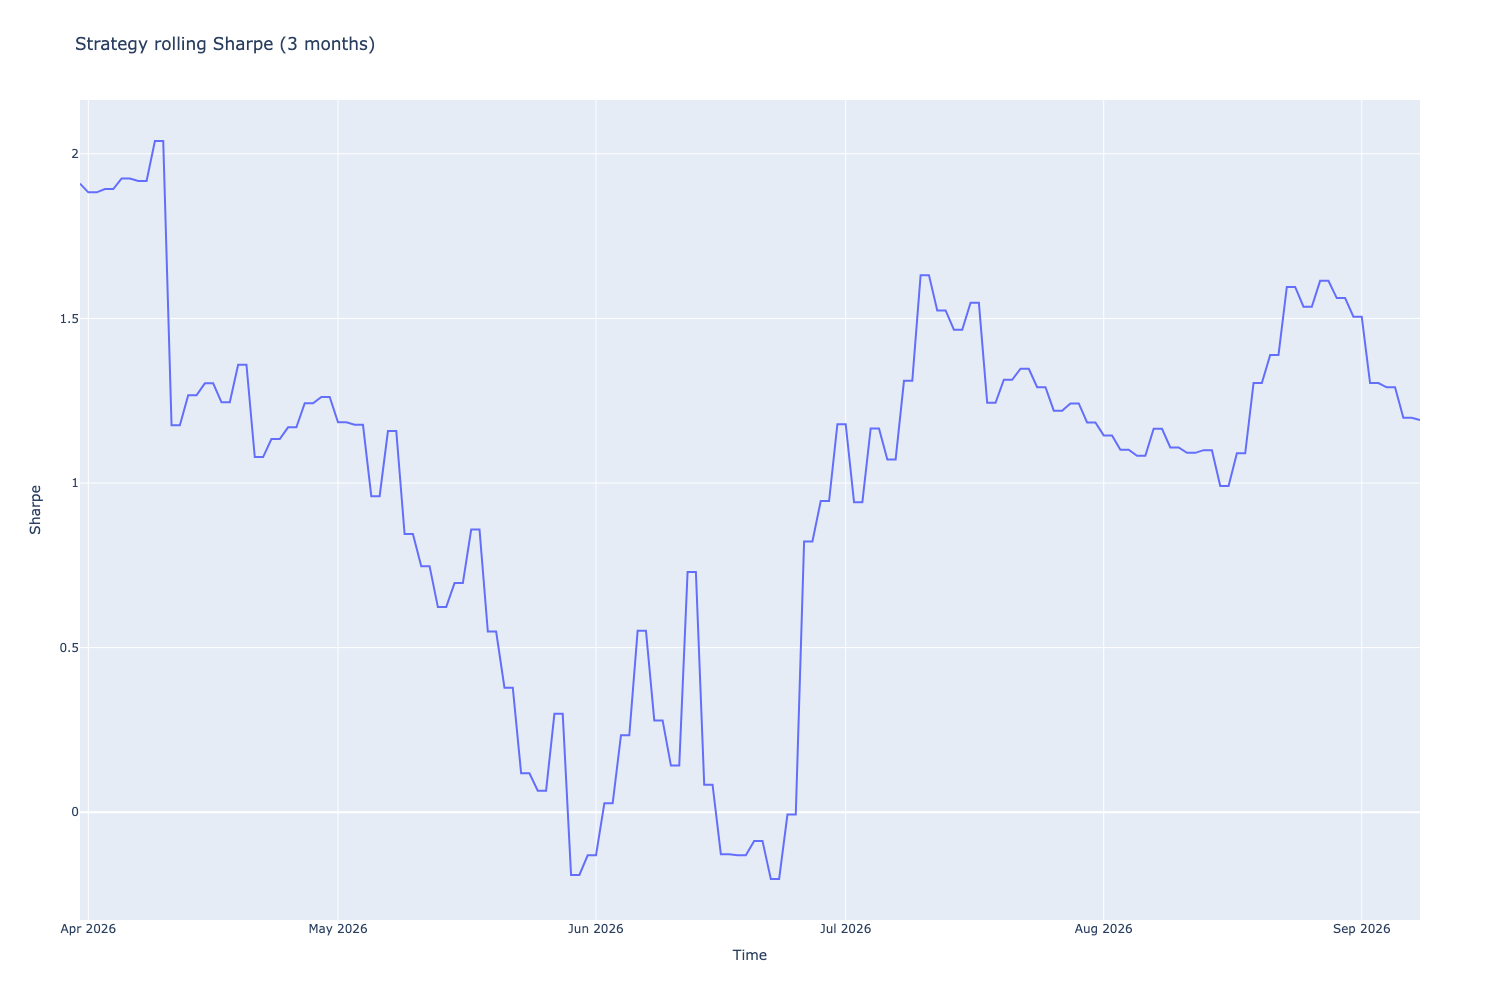

In [25]:
from tradeexecutor.visual.equity_curve import (
    calculate_rolling_returns,
    calculate_rolling_sharpe,
)

rolling_returns = calculate_rolling_returns(
    returns,
    freq="D",
    periods=90,
)

fig = px.line(rolling_returns, title="Strategy rolling compounded return (3 months)")
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Compounded return", tickformat=".0%")
fig.update_xaxes(title="Time")
fig.show()

rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=90,
)

fig = px.line(rolling_sharpe, title="Strategy rolling Sharpe (3 months)")
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()


# Monthly returns

- Check whether the path of returns is broad-based across months or dominated by a few bursts.


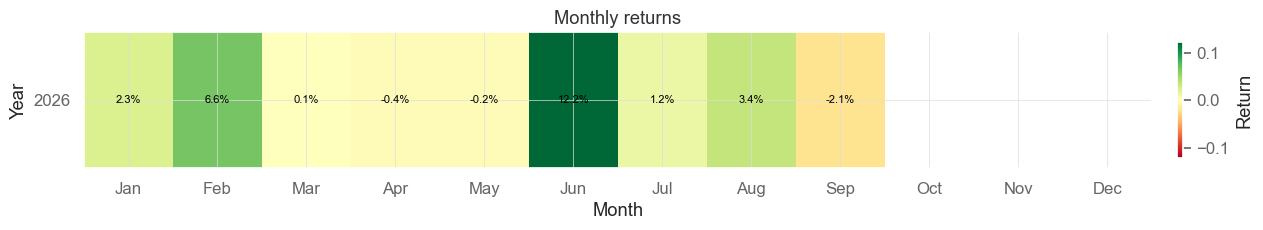

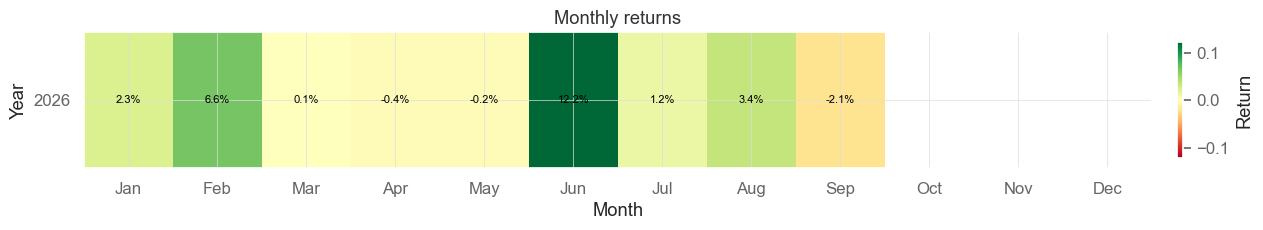

In [26]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time

monthly_returns_fig = visualise_returns_over_time(returns)
display(monthly_returns_fig)


# Positions at the end

- Inspect the live basket at the end of the backtest window.

In [27]:
stats = chart_renderer.render(positions_at_end)
display_head_and_tail(stats, head_rows=10, tail_rows=10)


,token,value,vault,protocol,link
position_id,,,,,
83,Citadel,60730.429142,Citadel,hyperliquid,0xda51323fe9800c8365646ad5c7ade0dd17fdc167
86,AceVault H,60422.907480,AceVault Hyper01,hyperliquid,0x9e02aca9865e1859bb7865f6f64801e804a173df
89,Octavious,12906.867888,Octavious Maximus,hyperliquid,0x45c42fbd450b5506f8dc819d46036630fe75b81e
90,Sequoia Hy,4665.821633,Sequoia HyperStable Yield Optimizer,hyperliquid,0xebc9865942ab666a57976a7768594b29133cbf53
94,DOEZOE,13302.081207,DOEZOE,hyperliquid,0xcae0d1558b70b92ee9fd0acb20cb639c8c28ae69
96,Mad Scient,11787.865019,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
